# 18b · 물체 검출: 격자마다 상자·신뢰도·클래스를 예측하기 (YOLO)

**이번 질문:** 지금까지 분류는 이미지 한 장에 답 하나였습니다. 한 이미지에 숫자가 여러 개 있고 그것이 **어디에** 있는지까지 맞혀야 하면 출력과 손실이 어떻게 바뀔까요?

05번의 합성곱은 "어느 자리에 무엇이 있나"를 적은 특성 맵을 만들었습니다. 그 특성 맵의 칸 하나를 이미지의 한 구역으로 보고, 칸마다 상자 네 숫자와 물체가 있을 만한 정도, 그리고 클래스를 내면 그대로 검출기가 됩니다.
겹침을 재는 자(IoU) → 격자 타깃 → 네 묶음 손실 → 백본과 head 학습 → 겹친 상자 정리와 평가 순서로 갑니다.

- 준비물: [05](../01_아키텍처/05_cnn.ipynb)의 합성곱·풀링·backward, [05b](../01_아키텍처/05b_lenet.ipynb)의 블록 쌓기, [14](../02_연결/14_losses_regularization.ipynb)의 손실 항 가중치와 평균 축, [15](../02_연결/15_experiments_evaluation.ipynb)의 precision·recall, [13](../02_연결/13_autodiff.ipynb)의 stop-gradient, [02](../00_기초/02_probability_and_losses.ipynb)의 sigmoid, [04](../00_기초/04_optimizers.ipynb)의 He 초기화와 Adam.
- 도착점: 격자 출력 텐서와 YOLO 손실을 직접 쓰고 중심차분으로 검산한 뒤, 작은 검출기를 학습시켜 NMS와 AP까지 돌립니다.
- 다음 연결: 같은 백본에서 화소마다 답을 내는 18 U-Net(분할)과, 검출에서 쓴 매칭·AP를 생성 모델에 옮기는 37 생성 모델 평가로 이어집니다. 두 노트북은 아직 없으므로 여기서는 링크를 두지 않습니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 상자는 $(c_x, c_y, w, h)$ 네 숫자이고 두 상자의 겹침은 **교집합 넓이 ÷ 합집합 넓이**(IoU) 하나입니다. 코드로는 `inter / (area_a + area_b - inter)`.
2. 출력은 격자 텐서 $(S, S, 5+K)$입니다($K$는 클래스 수). 물체의 **중심이 들어간 셀 하나**가 그 물체를 책임집니다. 코드로는 `col, row = int(cx * S), int(cy * S)`.
3. 손실은 좌표·obj 신뢰도·noobj 신뢰도·클래스 네 묶음의 제곱합이고, 어느 셀이 어느 항을 받는지는 mask가 정합니다. mask와 신뢰도 타깃을 상수로 고정하면 미분은 `2 * mask * (pred - target)` 꼴입니다.

| 기호 | shape | 의미 |
|---|---|---|
| $X$ | $(N,1,32,32)$ | 캔버스 배치 |
| $\hat y$ | $(N,S,S,5+K)$ | 격자 출력. 격자 $S=4$, 클래스 수 $K=10$이라 칸마다 15개 |
| $C$ | $(N,S,S)$ | 신뢰도 칸 $\hat y[\ldots,4]$. 클래스 수 $K$와 다른 기호입니다 |
| $1^{obj}$ | $(N,S,S)$ | 책임 셀 mask (True/False) |
| $b$ | $(\ldots,4)$ | 상자 $(c_x, c_y, w, h)$. 마지막 축만 4면 됩니다 |

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/detection_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src/utils/plotting.py").is_file())            # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(3절: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/detection_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist, load_examples
from src.utils.detection_plots import (
    plot_curves, plot_canvases, plot_iou_boxes, plot_grid_targets, plot_loss_terms,
    plot_detector_blocks, plot_detections, plot_nms_hand, plot_nms_result, plot_pr_curve,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· 물체 검출(YOLO) 준비 완료")

NumPy 2.4.6 · 물체 검출(YOLO) 준비 완료


### 📎 이 노트북의 예시: 숫자 캔버스

- **숫자 캔버스.** 32×32 빈 그림판에 MNIST 숫자를 1–3개 겹치지 않게 놓아 본문에서 만듭니다. 답은 숫자마다 (클래스, 중심 x, 중심 y, 너비, 높이)이고, 좌표는 캔버스 한 변을 1로 본 비율입니다. 학습 2,000장, 검증 200장을 서로 다른 난수와 서로 다른 MNIST 이미지로 만듭니다.
- **손계산용 상자.** 1절과 5절은 캔버스 위의 상자 두세 개를 정수로 직접 적어 IoU와 NMS를 손으로 따라갑니다.
- **격자 한 장.** 2–3절은 검증 캔버스 한 장을 계속 들여다보며 어느 셀이 어느 물체를 책임지는지 봅니다.

> **용어**
>
> - **MNIST**: 0–9 손글씨 숫자를 28×28 흑백 이미지로 모은 데이터. 이 노트북은 앞 5,000장만 쓰고, 가운데를 잘라 2×2 평균으로 줄인 10×10 숫자를 캔버스에 붙입니다.
> - **캔버스 데이터**: 이 노트북이 본문에서 만드는 작은 검출용 데이터. COCO·Pascal VOC 같은 실제 검출 데이터셋이 아니므로, 여기서 나오는 점수는 **학습용 작은 문제의 성능**으로만 읽습니다.

아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `_`: 함수가 돌려준 값 중 쓰지 않는 것을 받아 버리는 관례상의 이름입니다.
> - `[f(a) for a in 목록]`(리스트 컴프리헨션): 목록의 원소마다 같은 계산을 해서 새 목록을 만듭니다. `for cx, cy, _, _ in grid_boxes`처럼 원소가 배열이면 그 자리에서 이름으로 나눠 받고, 쓰지 않는 자리는 `_`로 버립니다.
> - `X.reshape(5000, 10, 2, 10, 2).mean(axis=(2, 4))`: 세로·가로를 (칸, 칸 안쪽 2) 로 쪼갠 뒤 안쪽 두 축을 평균으로 없앱니다. 20×20을 10×10으로 줄이는 2×2 평균 풀링입니다(05번 4절).
> - `rng.integers(a, b)`: a 이상 b 미만의 정수를 무작위로 하나 뽑습니다. `size=2`를 주면 두 개를 배열로 돌려줍니다.
> - `np.full((n, 3, 5), -1.0)`: −1로 채운 배열. 캔버스마다 물체 수가 달라서, 비어 있는 자리는 클래스 −1로 표시합니다.

In [2]:
mnist_examples, mnist_labels = load_examples(download=True)      # (10, 28, 28) 고정 예시 10장, (10,) 정답 숫자
mnist_X_all, mnist_y_all, _, _ = load_mnist()                    # (60000, 784), (60000,). 시험용 두 값은 안 쓰므로 _ 로 버립니다
mnist_X, mnist_y = mnist_X_all[:5000], mnist_y_all[:5000]        # (5000, 784), (5000,): 학습 집합 앞 5,000장
mnist_small = mnist_X.reshape(5000, 28, 28)[:, 4:24, 4:24].reshape(5000, 10, 2, 10, 2).mean(axis=(2, 4))   # (5000, 10, 10): 가운데 20×20을 2×2 평균으로 줄임
CANVAS, S, CELL, N_CLASSES = 32, 4, 8, 10                        # 캔버스 한 변, 격자 한 변, 셀 한 변(화소), 클래스 수
print("줄인 숫자", mnist_small.shape, "· 캔버스", CANVAS, "· 격자", S, "× 셀", CELL, "화소")

줄인 숫자 (5000, 10, 10) · 캔버스 32 · 격자 4 × 셀 8 화소


In [3]:
def digit_box(image, ink=0.1):
    """잉크가 ink보다 진한 화소를 감싸는 상자. image: (h, w) → (x1, y1, x2, y2) 화소 경계 (오른쪽·아래는 열린 끝)."""
    rows = np.where(image.max(axis=1) > ink)[0]      # (…,): 잉크가 있는 행 번호
    cols = np.where(image.max(axis=0) > ink)[0]      # (…,): 잉크가 있는 열 번호
    return np.array([cols[0], rows[0], cols[-1] + 1, rows[-1] + 1], dtype=float)

In [4]:
def make_canvases(digits, labels, n, rng, max_objects=3):
    """숫자 캔버스 n장과 정답. 셀이 겹치지 않는 자리에만 숫자를 붙입니다.
    digits: (M, 10, 10), labels: (M,) → (X: (n, 1, 32, 32), boxes: (n, max_objects, 5) = (클래스, cx, cy, w, h), 빈 자리는 −1)."""
    # 쓰는 것: CANVAS, CELL (📎 데이터 셀) · digit_box (📎 데이터 셀)
    X = np.zeros((n, 1, CANVAS, CANVAS))
    boxes = np.full((n, max_objects, 5), -1.0)
    for i in range(n):
        used_cells, placed = set(), []                                    # 이미 쓴 책임 셀과 이미 놓은 상자
        for _ in range(int(rng.integers(1, max_objects + 1))):            # 이 캔버스에 놓아 볼 숫자 수
            for _try in range(40):                                        # 자리를 40번까지 다시 뽑아 봅니다
                k = int(rng.integers(len(digits)))
                top, left = rng.integers(0, CANVAS - 10 + 1, size=2)      # 10×10 숫자가 들어갈 왼쪽 위
                x1, y1, x2, y2 = digit_box(digits[k]) + np.array([left, top, left, top])
                cell = (int((y1 + y2) / 2 // CELL), int((x1 + x2) / 2 // CELL))     # 중심이 속한 (행, 열) 셀
                overlap = any(x1 < qx2 + 1 and qx1 < x2 + 1 and y1 < qy2 + 1 and qy1 < y2 + 1 for qx1, qy1, qx2, qy2 in placed)
                if cell in used_cells or overlap:
                    continue
                used_cells.add(cell)
                placed.append((x1, y1, x2, y2))
                X[i, 0, top:top + 10, left:left + 10] = np.maximum(X[i, 0, top:top + 10, left:left + 10], digits[k])
                boxes[i, len(placed) - 1] = [labels[k], (x1 + x2) / 2 / CANVAS, (y1 + y2) / 2 / CANVAS,
                                             (x2 - x1) / CANVAS, (y2 - y1) / CANVAS]
                break
    return X, boxes

In [5]:
# 쓰는 것: mnist_small, mnist_y (📎 데이터 셀) · make_canvases (📎 데이터 셀)
canvas_X_train, canvas_labels_train = make_canvases(mnist_small[:4000], mnist_y[:4000], 2000, np.random.default_rng(1800))
canvas_X_valid, canvas_labels_valid = make_canvases(mnist_small[4000:], mnist_y[4000:], 200, np.random.default_rng(1801))
canvas_counts = (canvas_labels_train[:, :, 0] >= 0).sum(axis=1)      # (2000,): 캔버스마다 놓인 숫자 수
print("학습", canvas_X_train.shape, "· 검증", canvas_X_valid.shape)
print("캔버스당 숫자 수 평균", canvas_counts.mean(), "· 1개/2개/3개", np.bincount(canvas_counts)[1:])

학습 (2000, 1, 32, 32) · 검증 (200, 1, 32, 32)
캔버스당 숫자 수 평균 1.998 · 1개/2개/3개 [669 666 665]


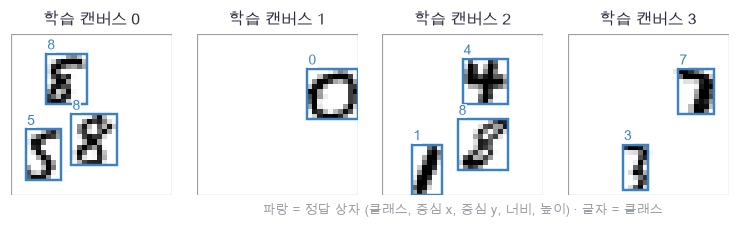

In [6]:
plot_canvases([canvas_X_train[k, 0] for k in range(4)],
              [canvas_labels_train[k][canvas_labels_train[k, :, 0] >= 0][:, 1:] for k in range(4)],
              [canvas_labels_train[k][canvas_labels_train[k, :, 0] >= 0][:, 0] for k in range(4)],
              titles=[f"학습 캔버스 {k}" for k in range(4)])

🔍 **확인** · 캔버스 한 장에 숫자가 1–3개 있고, 파란 상자가 정답입니다. 상자는 잉크가 있는 범위를 감싸므로 1처럼 가는 숫자는 좁고 0처럼 둥근 숫자는 넓습니다.
학습과 검증은 서로 다른 MNIST 이미지(앞 4,000장 / 뒤 1,000장)와 서로 다른 난수로 만들었으므로, 검증 캔버스의 숫자는 학습에서 본 적이 없습니다.

## 🔑 1. 상자 두 개가 얼마나 겹치는지를 숫자 하나로

**이 절에서 가져갈 것:** 상자를 (중심 x, 중심 y, 너비, 높이) 네 숫자로 적으면, 두 상자가 얼마나 포개지는지는 **교집합 넓이 ÷ 합집합 넓이**(IoU) 하나로 잽니다. 모서리로 바꿔 최솟값·최댓값을 취하는 식이라 브로드캐스팅으로 모든 쌍을 한 번에 계산합니다.

캔버스에 숫자가 하나 있고, 모델이 "여기쯤에 숫자가 있다"며 상자를 하나 내놓았습니다. 맞았다고 할지 틀렸다고 할지 정하려면 두 상자가 얼마나 포개지는지를 재는 자가 필요합니다. 중심이 조금 어긋나도 크게 포개졌으면 맞은 것으로 봐야 합니다.

> **용어**
>
> - **물체 검출(object detection)**: 이미지 안의 물체마다 **무엇인지**(클래스)와 **어디인지**(상자)를 함께 답하는 문제. 분류는 이미지 한 장에 답 하나였습니다.
> - **상자(bounding box)** $b$: 물체를 감싸는, 축에 나란한 직사각형. 이 노트북은 $(c_x, c_y, w, h)$ = (중심 x, 중심 y, 너비, 높이) 네 숫자로 적습니다. 코드에서는 마지막 축 길이가 4인 배열입니다.
> - **IoU(Intersection over Union)**: 교집합 넓이를 합집합 넓이로 나눈 값. 0이면 전혀 안 겹치고 1이면 완전히 같습니다. 검출에서는 보통 0.5를 "맞았다"의 경계로 씁니다.

상자 $b=(c_x,c_y,w,h)$의 네 모서리는 중심에서 절반씩 간 자리입니다.
$$x_1=c_x-\frac{w}{2},\qquad y_1=c_y-\frac{h}{2},\qquad x_2=c_x+\frac{w}{2},\qquad y_2=c_y+\frac{h}{2}.$$

겹친 가로 길이와 세로 길이는 각각 "작은 쪽 오른쪽 − 큰 쪽 왼쪽"이고, 음수면 안 겹친 것이므로 0으로 자릅니다.
$$w_\cap=\max\big(0,\ \min(x_2^A,x_2^B)-\max(x_1^A,x_1^B)\big),\qquad
h_\cap=\max\big(0,\ \min(y_2^A,y_2^B)-\max(y_1^A,y_1^B)\big).$$

$$\mathrm{IoU}(A,B)=\frac{w_\cap h_\cap}{w_Ah_A+w_Bh_B-w_\cap h_\cap}.$$

분모는 두 넓이를 더한 뒤, 두 번 센 교집합을 한 번 빼 준 합집합 넓이입니다.

shape 규약: $A$가 $(M,4)$, $B$가 $(K,4)$일 때 `A[:, None]` $(M,1,4)$와 `B[None]` $(1,K,4)$를 넣으면 결과는 $(M,K)$입니다. 00b번 3절에서 이미지 쌍마다 거리를 잰 것과 같은 꼴입니다. 상자 축이 마지막이기만 하면 $(N,S,S,4)$ 두 개를 넣어 $(N,S,S)$를 받을 수도 있습니다.

손계산: $A=(12,12,12,12)$는 모서리 $(6,6)$–$(18,18)$이라 넓이 144, $B=(18,15,12,6)$은 $(12,12)$–$(24,18)$이라 넓이 72입니다. 겹친 부분은 가로 $18-12=6$, 세로 $18-12=6$이므로 36이고, 합집합은 $144+72-36=180$, IoU는 $36/180=0.2$입니다.

> **코드**
>
> - `np.clip(a, 0, None)`: 0보다 작은 값을 0으로 자릅니다. 위쪽은 `None`이라 자르지 않습니다.
> - `box[..., 0]`: `...`은 "앞 축 전부"입니다. 마지막 축의 0번 칸(중심 x)만 고르므로 $(M,4)$든 $(N,S,S,4)$든 같은 코드가 됩니다.
> - `A[:, None]` / `B[None]`: 길이 1인 축을 끼워 넣어 모든 쌍을 한 번에 계산합니다(00b번 3절).

In [7]:
# 쓰는 것: CANVAS (📎 데이터 셀)
iou_box_a = np.array([12., 12., 12., 12.])                 # (4,): 중심 (12, 12)의 12×12 상자
iou_box_b = np.array([18., 15., 12., 6.])                  # (4,): 중심 (18, 15)의 12×6 상자
iou_a1, iou_a2 = iou_box_a[:2] - iou_box_a[2:] / 2, iou_box_a[:2] + iou_box_a[2:] / 2    # (2,) 둘: A의 왼쪽 위와 오른쪽 아래
iou_b1, iou_b2 = iou_box_b[:2] - iou_box_b[2:] / 2, iou_box_b[:2] + iou_box_b[2:] / 2
iou_side = np.clip(np.minimum(iou_a2, iou_b2) - np.maximum(iou_a1, iou_b1), 0, None)     # (2,): 겹친 가로·세로 길이
iou_area_a, iou_area_b = iou_box_a[2] * iou_box_a[3], iou_box_b[2] * iou_box_b[3]        # 넓이 = 너비 × 높이
iou_area_inter = iou_side[0] * iou_side[1]
iou_hand = iou_area_inter / (iou_area_a + iou_area_b - iou_area_inter)
iou_corners = np.concatenate([np.maximum(iou_a1, iou_b1), np.minimum(iou_a2, iou_b2)])   # (4,): 교집합 사각형 (x1, y1, x2, y2)
iou_canvas = np.zeros((CANVAS, CANVAS))                    # (32, 32): 상자만 보려고 비워 둔 캔버스
print("겹친 가로·세로", iou_side, "· 넓이 A", iou_area_a, "B", iou_area_b, "교집합", iou_area_inter)
print("합집합", iou_area_a + iou_area_b - iou_area_inter, "· IoU =", iou_hand)

겹친 가로·세로 [6. 6.] · 넓이 A 144.0 B 72.0 교집합 36.0
합집합 180.0 · IoU = 0.2


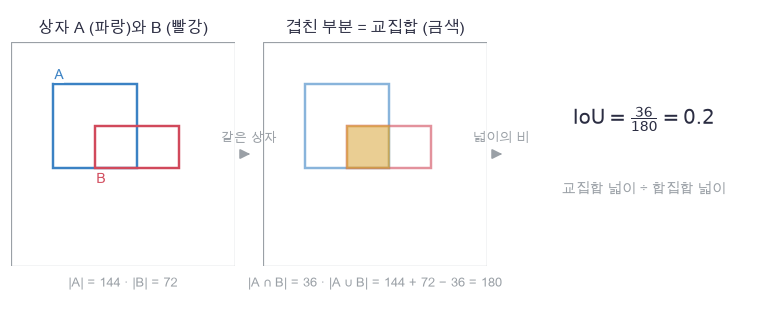

In [8]:
plot_iou_boxes(iou_canvas, iou_box_a, iou_box_b, iou_corners, (iou_area_a, iou_area_b, iou_area_inter))

🔍 **확인** · 왼쪽은 상자 두 개, 가운데 금색이 두 상자가 함께 덮은 교집합 6×6입니다. 오른쪽 식의 분자가 그 36이고 분모는 두 넓이의 합에서 36을 한 번 뺀 180입니다.
상자가 점점 멀어지면 분자가 0이 되어 IoU도 0이고, 완전히 겹치면 분자와 분모가 같아져 1입니다. 아래 구현은 이 두 줄을 배열 전체에 한 번에 적용합니다.

In [9]:
def box_corners(boxes):
    """상자를 모서리로. (cx, cy, w, h) → (x1, y1, x2, y2). boxes: (..., 4) → 각각 (...,) 인 네 배열."""
    half_w, half_h = boxes[..., 2] / 2, boxes[..., 3] / 2
    return boxes[..., 0] - half_w, boxes[..., 1] - half_h, boxes[..., 0] + half_w, boxes[..., 1] + half_h


def box_iou(A, B):
    """두 상자 묶음의 IoU = 교집합 넓이 ÷ 합집합 넓이. A, B: (..., 4) (브로드캐스팅되는 모양) → (...,)."""
    ax1, ay1, ax2, ay2 = box_corners(A)
    bx1, by1, bx2, by2 = box_corners(B)
    inter_w = np.clip(np.minimum(ax2, bx2) - np.maximum(ax1, bx1), 0, None)   # 겹친 가로 길이 (음수는 0)
    inter_h = np.clip(np.minimum(ay2, by2) - np.maximum(ay1, by1), 0, None)
    inter = inter_w * inter_h
    union = A[..., 2] * A[..., 3] + B[..., 2] * B[..., 3] - inter             # 두 넓이의 합에서 교집합을 한 번 뺀 것
    return inter / np.maximum(union, 1e-12)                                    # 넓이가 0인 상자에서 0으로 나누지 않게

In [10]:
# 쓰는 것: iou_box_a, iou_box_b, iou_hand (1절 손계산 셀) · canvas_labels_valid (📎 데이터 셀)
np.testing.assert_allclose(box_iou(iou_box_a, iou_box_b), 0.2)          # 검산: 손계산 36 / 180 = 0.2
np.testing.assert_allclose(box_iou(iou_box_a, iou_box_b), iou_hand)     # 검산: 위 그림의 값과 같음
np.testing.assert_allclose(box_iou(iou_box_a, iou_box_a), 1.0)          # 검산: 자기 자신과는 교집합 = 합집합
np.testing.assert_allclose(box_iou(iou_box_a, np.array([30., 30., 4., 4.])), 0.0)   # 검산: 떨어진 상자는 0
gt_pairs = canvas_labels_valid[0][canvas_labels_valid[0, :, 0] >= 0][:, 1:]         # (물체 수, 4): 검증 캔버스 0의 정답 상자
gt_matrix = box_iou(gt_pairs[:, None], gt_pairs[None])                             # (물체 수, 물체 수): 모든 쌍
np.testing.assert_allclose(gt_matrix, gt_matrix.T)                                  # 검산: IoU는 대칭
np.testing.assert_allclose(np.diag(gt_matrix), 1.0)                                 # 검산: 대각선은 자기 자신이라 1
print("모든 쌍의 IoU 표", gt_matrix.shape, "\n", gt_matrix)

모든 쌍의 IoU 표 (3, 3) 
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


🔍 **확인** · 손계산 0.2, 자기 자신 1, 떨어진 상자 0이 모두 맞습니다. 검증 캔버스 한 장의 정답 상자끼리 만든 표는 대각선이 1이고 나머지가 0입니다. 캔버스를 만들 때 숫자들이 겹치지 않게 놓았기 때문입니다.
같은 함수가 $(4,)$ 상자 하나와 $(M,1,4)\times(1,K,4)$ 모든 쌍을 함께 처리합니다. 마지막 축만 4면 되기 때문입니다.

### ✏️ 연습 1 · 교집합 넓이 한 줄

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

상자 두 개 `box_a`, `box_b` `(4,)`의 **교집합 넓이** 한 줄을 채우세요. 모서리를 푸는 줄은 써 두었습니다. 겹친 가로 길이와 세로 길이를 각각 0으로 자른 뒤 곱하면 됩니다. 검사는 1절 손계산 36과 떨어진 상자 0, 자기 자신(= 자기 넓이)으로 합니다.

In [11]:

def exercise_intersection_area(box_a, box_b):
    """연습 1: 상자 두 개의 교집합 넓이. box_a, box_b: (4,) = (중심 x, 중심 y, 너비, 높이) → 숫자 하나."""
    ax1, ay1, ax2, ay2 = box_corners(box_a)               # 1절 box_corners: 왼쪽 위와 오른쪽 아래
    bx1, by1, bx2, by2 = box_corners(box_b)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 겹친 가로 길이 × 겹친 세로 길이인 area (숫자 하나). 안 겹치면 0이어야 합니다
    ### 힌트: 1절 box_iou의 inter_w · inter_h 두 줄을 곱한 것입니다. "작은 쪽 오른쪽 − 큰 쪽 왼쪽"을 np.clip(…, 0, None)으로 자릅니다.
    raise NotImplementedError
    return area


In [12]:

def check_intersection_area(candidate):
    """1절 손계산 36과 떨어진 상자 0, 자기 자신(= 자기 넓이)으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: box_corners (1절)
    example_a = np.array([12., 12., 12., 12.])                        # (4,): 모서리 (6, 6)–(18, 18), 넓이 144
    example_b = np.array([18., 15., 12., 6.])                         # (4,): 모서리 (12, 12)–(24, 18), 넓이 72
    actual = candidate(example_a, example_b)
    assert np.ndim(actual) == 0, f"교집합 넓이는 숫자 하나여야 하는데 모양이 {np.shape(actual)}입니다"
    np.testing.assert_allclose(actual, 36.)                           # 검산: 손계산. 겹친 가로 6 × 세로 6
    np.testing.assert_allclose(candidate(example_a, example_a), 144.)  # 검산: 자기 자신과의 교집합 = 자기 넓이 12 × 12
    np.testing.assert_allclose(candidate(example_a, np.array([30., 30., 4., 4.])), 0.)   # 검산: 떨어진 상자는 0
    np.testing.assert_allclose(candidate(example_a, np.array([12., 30., 12., 12.])), 0.) # 검산: 세로로만 떨어져도 0
    print("교집합 넓이: 손계산과 일치합니다.")


run_check(check_intersection_area, exercise_intersection_area,
          hint="area = np.clip(np.minimum(ax2, bx2) - np.maximum(ax1, bx1), 0, None) * np.clip(np.minimum(ay2, by2) - np.maximum(ay1, by1), 0, None)")


☐ exercise_intersection_area: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: area = np.clip(np.minimum(ax2, bx2) - np.maximum(ax1, bx1), 0, None) * np.clip(np.minimum(ay2, by2) - np.maximum(ay1, by1), 0, None)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
area = np.clip(np.minimum(ax2, bx2) - np.maximum(ax1, bx1), 0, None) * np.clip(np.minimum(ay2, by2) - np.maximum(ay1, by1), 0, None)
```

</details>

## 🔑 2. 격자 셀 하나가 물체 하나를 책임집니다

**이 절에서 가져갈 것:** 출력은 격자 텐서 $(S,S,5+K)$이고, 물체의 **중심이 들어간 셀 하나**가 그 물체를 책임집니다. 그 셀의 칸에는 셀 안 상대 좌표 $(t_x,t_y)\in[0,1)$, 캔버스 비율 너비·높이, 신뢰도 1, 클래스 one-hot을 적습니다. 나머지 셀은 "물체 없음"입니다.

캔버스를 4×4로 나누어 16칸을 만들고, 칸마다 답안지를 한 장씩 나눠 준다고 생각하면 됩니다. 숫자의 중심이 내 칸에 들어왔으면 나는 그 숫자의 상자와 이름을 적고, 아니면 "여기엔 없다"고만 적습니다. 이렇게 하면 물체 수가 달라도 출력의 모양이 항상 같습니다.

> **용어**
>
> - **격자 셀(grid cell)**: 이미지를 $S\times S$로 나눈 칸 하나. 이 노트북은 $S=4$이므로 셀 하나가 32/4 = 8화소입니다.
> - **책임 셀(responsible cell)**: 물체의 중심이 들어간 셀. 그 물체의 상자·클래스를 맞힐 책임을 그 셀 하나가 집니다.
> - **신뢰도(confidence)** $C$: "이 셀에 물체가 있고 내 상자가 정답과 잘 포개진다"는 정도를 나타내는 0–1 숫자. 타깃은 3절에서 IoU로 정합니다. 클래스 수는 $K$로 적어 신뢰도 $C$와 구별합니다($K=10$).
> - **one-hot**: 정답 칸만 1이고 나머지가 0인 길이 $K$ 벡터(02번 8절). 클래스 10개면 10칸입니다.

중심 $(c_x,c_y)$는 캔버스 한 변을 1로 본 비율입니다. 책임 셀의 (행, 열)과 셀 안 상대 좌표는
$$\text{col}=\lfloor c_xS\rfloor,\quad \text{row}=\lfloor c_yS\rfloor,\qquad
t_x=c_xS-\text{col},\quad t_y=c_yS-\text{row}.$$

$\lfloor a\rfloor$는 $a$ 이하의 가장 큰 정수입니다. $c_xS$의 정수 부분이 몇 번째 칸인지, 소수 부분이 그 칸 안 어디인지를 말합니다. 너비·높이 $t_w=w,\ t_h=h$는 셀이 아니라 **캔버스** 비율로 둡니다. 물체가 셀보다 클 수 있기 때문입니다.

되돌리는 식(디코딩)은 같은 줄을 거꾸로 읽은 것입니다.
$$c_x=\frac{\text{col}+t_x}{S},\qquad c_y=\frac{\text{row}+t_y}{S}.$$

타깃 텐서의 shape는 $(N,S,S,5+K)=(N,4,4,15)$이고, 칸 15개의 순서는 $[t_x,t_y,t_w,t_h,C,p_0,\ldots,p_{K-1}]$입니다. 책임 셀 mask $1^{obj}$는 $(N,S,S)$의 True/False 배열입니다.

> **코드**
>
> - `int(cx * S)`: 양수에서 `int()`는 내림입니다. `np.floor` 대신 쓰면 그대로 정수 인덱스가 됩니다.
> - `np.eye(10)[cls]`: 10×10 단위행렬의 `cls`번째 행 = one-hot(00b번 4절). 아래 코드는 같은 일을 `target[..., 5 + cls] = 1`로 합니다.
> - `np.meshgrid(np.arange(S), np.arange(S), indexing="ij")`: 셀마다의 행 번호 표와 열 번호 표 두 개 `(S, S)`. `indexing="ij"`라야 첫 축이 행입니다.
> - `labels[k, :, 0] >= 0`: 빈 자리(−1)를 걸러 내는 mask. 실제 물체만 남깁니다.
> - `zip(a, b, c)`: 세 목록을 앞에서부터 짝지어 한 번에 하나씩 꺼냅니다. 꺼낸 묶음은 `for (row, col), (cx, cy, w, h), cls in zip(...)`처럼 그 자리에서 이름으로 나눠 받을 수 있습니다.
> - `np.stack([...], axis=-1)`: 같은 모양의 배열 여러 개를 새로 만든 **마지막** 축으로 쌓습니다. `(S, S)` 네 개 → `(S, S, 4)`.
> - `np.column_stack([a, b])`: 배열들을 열로 세워 옆으로 붙입니다. `(K,)`와 `(K, 4)` → `(K, 5)`.

In [13]:
# 쓰는 것: mnist_examples, CANVAS, CELL (📎 데이터 셀) · digit_box (📎 데이터 셀)
mnist_examples_small = mnist_examples[:, 4:24, 4:24].reshape(10, 10, 2, 10, 2).mean(axis=(2, 4))   # (10, 10, 10): 고정 예시 10장을 같은 방법으로 줄임
grid_places = [(7, 3, 5), (3, 19, 18)]                   # (숫자, 위, 왼쪽): 고정 예시 7과 3을 손으로 놓습니다
grid_canvas = np.zeros((CANVAS, CANVAS))                 # (32, 32)
grid_boxes, grid_classes = [], []
for digit, top, left in grid_places:
    grid_canvas[top:top + 10, left:left + 10] = mnist_examples_small[digit]
    x1, y1, x2, y2 = digit_box(mnist_examples_small[digit]) + np.array([left, top, left, top])   # 캔버스 화소 좌표의 모서리
    grid_boxes.append([(x1 + x2) / 2 / CANVAS, (y1 + y2) / 2 / CANVAS, (x2 - x1) / CANVAS, (y2 - y1) / CANVAS])
    grid_classes.append(digit)
grid_boxes = np.array(grid_boxes)                        # (2, 4): 캔버스 비율 (cx, cy, w, h)
grid_classes = np.array(grid_classes)                    # (2,)
print("정답 상자 (캔버스 비율)\n", grid_boxes, "\n클래스", grid_classes)

정답 상자 (캔버스 비율)
 [[0.2812 0.2656 0.1875 0.2812]
 [0.7031 0.75   0.2812 0.3125]] 
클래스 [7 3]


In [14]:
# 쓰는 것: S, N_CLASSES (📎 데이터 셀) · grid_boxes, grid_classes (2절 캔버스 셀)
grid_cells = [(int(cy * S), int(cx * S)) for cx, cy, _, _ in grid_boxes]     # 물체마다 (행, 열) = 중심 × S 의 내림
grid_obj = np.zeros((S, S))                                                  # (4, 4): 책임 셀이면 1
grid_target = np.zeros((S, S, 5 + N_CLASSES))                                # (4, 4, 15): 셀마다 답안지 15칸
for (row, col), (cx, cy, w, h), cls in zip(grid_cells, grid_boxes, grid_classes):
    grid_obj[row, col] = 1.0
    grid_target[row, col, 0:2] = [cx * S - col, cy * S - row]                # 셀 안 상대 좌표 t_x, t_y ∈ [0, 1)
    grid_target[row, col, 2:4] = [w, h]                                      # 너비·높이는 캔버스 비율 그대로
    grid_target[row, col, 4] = 1.0                                           # 신뢰도 타깃 (3절에서 IoU로 바꿉니다)
    grid_target[row, col, 5 + int(cls)] = 1.0                                # 클래스 one-hot
grid_highlight = grid_cells[0]                                               # 그림에서 금색으로 볼 셀: 고정 예시 7의 책임 셀
print("책임 셀 (행, 열)", grid_cells, "· 7의 셀", grid_highlight)
print("그 셀의 타깃 15칸\n", grid_target[grid_highlight])

책임 셀 (행, 열) [(1, 1), (3, 2)] · 7의 셀 (1, 1)
그 셀의 타깃 15칸
 [0.125  0.0625 0.1875 0.2812 1.     0.     0.     0.     0.     0.
 0.     0.     1.     0.     0.    ]


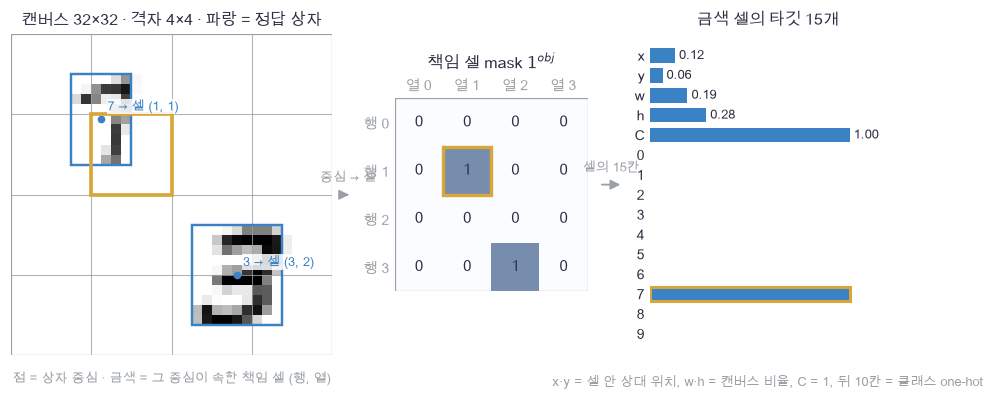

In [15]:
plot_grid_targets(grid_canvas, S, grid_boxes, grid_classes, grid_cells, grid_highlight, grid_obj, grid_target[grid_highlight])

🔍 **확인** · 왼쪽 캔버스의 점이 상자 중심이고, 금색 테두리가 그 중심이 들어간 셀입니다. 가운데 표는 셀 16개 중 책임 셀 두 곳만 1인 mask $1^{obj}$입니다.
오른쪽은 금색 셀의 답안지 15칸입니다. $t_x, t_y$는 셀 안에서의 위치라 0과 1 사이이고, $w, h$는 캔버스 비율이라 작은 값이며, 신뢰도는 1, 클래스 칸은 7번만 1입니다.
물체가 셋이면 1이 셋이 되고 나머지 셀은 그대로입니다. 출력 텐서의 모양은 물체 수와 상관없이 언제나 $(4,4,15)$입니다.

In [16]:
def encode_targets(labels, S):
    """정답 목록을 격자 타깃 텐서로. 물체마다 중심이 든 셀에 [t_x, t_y, w, h, 1, one-hot]을 적습니다.
    labels: (N, K, 5) = (클래스, cx, cy, w, h) (빈 자리는 −1), S: 격자 한 변 → (target: (N, S, S, 15), obj: (N, S, S) bool)."""
    # 쓰는 것: N_CLASSES (📎 데이터 셀)
    N, K, _ = labels.shape
    target = np.zeros((N, S, S, 5 + N_CLASSES))
    obj = np.zeros((N, S, S), dtype=bool)
    for n in range(N):
        for k in range(K):
            cls, cx, cy, w, h = labels[n, k]
            if cls < 0:                                       # 빈 자리는 건너뜁니다
                continue
            col, row = int(cx * S), int(cy * S)               # 책임 셀 (열, 행)
            target[n, row, col, 0:2] = [cx * S - col, cy * S - row]
            target[n, row, col, 2:4] = [w, h]
            target[n, row, col, 4] = 1.0
            target[n, row, col, 5 + int(cls)] = 1.0
            obj[n, row, col] = True
    return target, obj

In [17]:
def decode_boxes(pred):
    """격자 출력의 앞 네 칸을 캔버스 비율 상자로: c_x = (col + t_x) / S, c_y = (row + t_y) / S.
    pred: (..., S, S, 5+K) → (..., S, S, 4) = (cx, cy, w, h)."""
    S_grid = pred.shape[-2]
    rows, cols = np.meshgrid(np.arange(S_grid), np.arange(S_grid), indexing="ij")   # (S, S) 둘: 셀의 행 번호와 열 번호
    return np.stack([(cols + pred[..., 0]) / S_grid, (rows + pred[..., 1]) / S_grid,
                     pred[..., 2], pred[..., 3]], axis=-1)

In [18]:
# 쓰는 것: canvas_labels_train, canvas_labels_valid, S (📎 데이터 셀) · grid_boxes, grid_classes, grid_cells, grid_obj, grid_target (2절 계산 셀)
target_train, obj_train = encode_targets(canvas_labels_train, S)     # (2000, 4, 4, 15), (2000, 4, 4)
target_valid, obj_valid = encode_targets(canvas_labels_valid, S)     # (200, 4, 4, 15), (200, 4, 4)
hand_labels = np.column_stack([grid_classes, grid_boxes])[None]      # (1, 2, 5): 위 그림의 캔버스를 정답 목록 모양으로
hand_target, hand_obj = encode_targets(hand_labels, S)
np.testing.assert_allclose(hand_target[0], grid_target)              # 검산: 손으로 채운 타깃과 같음
np.testing.assert_allclose(hand_obj[0], grid_obj.astype(bool))       # 검산: 손으로 채운 mask와 같음
assert hand_obj.sum() == 2, "물체 두 개는 서로 다른 셀 두 개를 차지해야 합니다"
decoded = decode_boxes(target_train)                                  # (2000, 4, 4, 4): 타깃을 다시 캔버스 좌표로
true_boxes = canvas_labels_train[canvas_labels_train[:, :, 0] >= 0][:, 1:]        # (물체 수, 4): 원래 정답 상자
np.testing.assert_allclose(np.sort(decoded[obj_train], axis=0), np.sort(true_boxes, axis=0), atol=1e-12)   # 검산: encode → decode 왕복이 원래 상자
print("타깃", target_train.shape, "· 책임 셀 수", int(obj_train.sum()), "= 물체 수", len(true_boxes))
print("왕복 최대 오차", np.abs(np.sort(decoded[obj_train], axis=0) - np.sort(true_boxes, axis=0)).max())

타깃 (2000, 4, 4, 15) · 책임 셀 수 3996 = 물체 수 3996
왕복 최대 오차 0.0


🔍 **확인** · `encode_targets`가 손으로 채운 타깃·mask와 정확히 같고, 책임 셀 수가 물체 수와 같습니다. 두 물체가 같은 셀에 들어갔다면 하나가 지워져 셀 수가 더 적었을 것입니다. 캔버스를 만들 때 셀이 겹치지 않게 놓아 이 문제를 피했습니다.
타깃을 다시 캔버스 좌표로 푼 값이 원래 상자와 $10^{-12}$ 안에서 같습니다. 인코딩과 디코딩이 서로의 역이라는 뜻이고, 모델 출력에도 같은 디코딩을 그대로 씁니다.

📎 물체가 셀 하나에 여러 개 들어가는 상황이 실제 데이터에서는 자주 생깁니다. YOLO v1은 셀마다 상자를 $B=2$개 두고 그중 IoU가 큰 쪽에 책임을 맡겼고, 이후 버전은 크기가 다른 anchor 상자 여러 개를 두거나 여러 해상도의 격자를 함께 씁니다. 여기서는 캔버스를 만들 때 중심이 같은 셀에 오지 않게 했으므로 셀마다 상자 하나($B=1$)로 충분합니다.

### ✏️ 연습 2 · 책임 셀 인덱스

중심 `cx`, `cy`(캔버스 비율)와 격자 크기 `S`에서 **책임 셀의 (행, 열)** 을 내는 한 줄을 채우세요. 행은 세로 좌표에서, 열은 가로 좌표에서 나오는 점에 주의하세요. 검사는 손계산 세 경우와 2절 그림의 책임 셀로 합니다.

In [19]:

def exercise_responsible_cell(cx, cy, S):
    """연습 2: 중심이 들어간 격자 셀. cx, cy: 0 이상 1 미만 숫자, S: 격자 한 변 → (row, col) 정수 두 개."""
    assert 0 <= cx < 1, "중심 x는 캔버스 비율이라 0 이상 1 미만이어야 합니다"
    assert 0 <= cy < 1, "중심 y는 캔버스 비율이라 0 이상 1 미만이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: row, col = 중심에 S를 곱해 내림한 정수 두 개 (행은 세로 cy에서, 열은 가로 cx에서)
    ### 힌트: 2절 수식 col = ⌊cx·S⌋, row = ⌊cy·S⌋ 그대로입니다. 양수에서 int()가 내림입니다.
    raise NotImplementedError
    return row, col


In [20]:

def check_responsible_cell(candidate):
    """손계산 세 경우와 2절 그림의 책임 셀로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: grid_boxes, grid_cells (2절 계산 셀)
    assert candidate(0.1, 0.1, 4) == (0, 0), "0.1 × 4 = 0.4 → 내림 0이므로 셀 (0, 0)이어야 합니다"
    assert candidate(0.9, 0.3, 4) == (1, 3), "가로 0.9 × 4 = 3.6 → 열 3, 세로 0.3 × 4 = 1.2 → 행 1이어야 합니다"
    assert candidate(0.5, 0.5, 4) == (2, 2), "경계 0.5 × 4 = 2.0 은 오른쪽·아래 셀에 들어가 (2, 2)여야 합니다"
    assert candidate(0.5, 0.5, 3) == (1, 1), "S = 3이면 0.5 × 3 = 1.5 → 내림 1이므로 (1, 1)이어야 합니다"
    for box, cell in zip(grid_boxes, grid_cells):
        assert candidate(box[0], box[1], 4) == cell, "2절 그림에서 읽은 책임 셀과 같아야 합니다"
    print("책임 셀 인덱스: 손계산과 일치합니다.")


run_check(check_responsible_cell, exercise_responsible_cell, hint="row, col = int(cy * S), int(cx * S)")


☐ exercise_responsible_cell: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: row, col = int(cy * S), int(cx * S)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
row, col = int(cy * S), int(cx * S)
```

</details>

## 🔑 3. 네 묶음의 제곱합과, mask를 상수로 본 미분

**이 절에서 가져갈 것:** 손실은 좌표·obj 신뢰도·noobj 신뢰도·클래스 네 묶음의 제곱합입니다. 어느 셀이 어느 항을 받는지는 mask $1^{obj}$가 정하므로, mask와 신뢰도 타깃을 **상수로 고정**하면 미분은 mask를 곱한 $2(\hat y-y)$입니다. 너비·높이만 $\sqrt{\ }$ 안에서 빼므로 그 자리의 미분에 $1/(2\sqrt{\hat w})$가 붙습니다.

셀 16개 중 물체가 있는 것은 보통 두 개뿐입니다. 빈 셀 14개까지 상자와 클래스를 맞히라고 하면 손실이 "아무것도 없다"는 말만 학습합니다. 그래서 항마다 **누가 받는지**와 **얼마나 세게 받는지**를 따로 정합니다.

> **용어**
>
> - **mask** $1^{obj}_{ij}$: 셀 $(i,j)$가 책임 셀이면 1, 아니면 0. 코드에서는 True/False 배열이고 곱하면 0/1처럼 동작합니다.
> - **$\lambda_{coord}$, $\lambda_{noobj}$**: 항마다의 가중치(14번 2절). 좌표는 중요하니 5배로 키우고, 빈 셀이 훨씬 많은 noobj 항은 0.5배로 줄입니다.
> - **stop-gradient**: 어떤 값을 계산에는 쓰되 미분에서는 상수로 보는 것(13번 5절). 신뢰도 타깃 IoU에 이것을 씁니다.

$N$장의 배치에서 손실은 캔버스마다 네 묶음을 더하고 캔버스 축에서 평균낸 것입니다.

$$L=\frac{1}{N}\sum_{n}\big(L^{coord}_n+L^{obj}_n+L^{noobj}_n+L^{cls}_n\big),$$

$$L^{coord}_n=\lambda_{coord}\sum_{i,j}1^{obj}_{ij}\big[(\hat t_x-t_x)^2+(\hat t_y-t_y)^2+(\sqrt{\hat t_w}-\sqrt{t_w})^2+(\sqrt{\hat t_h}-\sqrt{t_h})^2\big],$$

$$L^{obj}_n=\sum_{i,j}1^{obj}_{ij}(\hat C-C)^2,\qquad
L^{noobj}_n=\lambda_{noobj}\sum_{i,j}(1-1^{obj}_{ij})\hat C^2,\qquad
L^{cls}_n=\sum_{i,j}1^{obj}_{ij}\sum_{c}(\hat p_c-p_c)^2.$$

네 줄 모두 셀 $(i,j)$ 전체를 더한 것이고, 캔버스 축에서만 평균을 냅니다. 위 첨자는 차례로 좌표·obj 신뢰도·noobj 신뢰도·클래스 묶음입니다.

너비·높이에 $\sqrt{\ }$를 씌우는 이유는 큰 상자와 작은 상자의 오차를 비슷하게 취급하기 위해서입니다. 0.5에서 0.6으로 어긋난 것과 0.05에서 0.15로 어긋난 것은, 제곱 오차로만 보면 뒤쪽이 더 작지만 물체를 놓친 정도는 뒤쪽이 훨씬 큽니다.

미분은 mask와 $C$를 상수로 보면 제곱의 미분 네 줄입니다. 칸별로 적으면
$$\frac{\partial L}{\partial \hat t_x}=\frac{2\lambda_{coord}}{N}1^{obj}(\hat t_x-t_x),\qquad
\frac{\partial L}{\partial \hat t_w}=\frac{2\lambda_{coord}}{N}1^{obj}(\sqrt{\hat t_w}-\sqrt{t_w})\cdot\frac{1}{2\sqrt{\hat t_w}},$$
$$\frac{\partial L}{\partial \hat C}=\frac{2}{N}\big[1^{obj}(\hat C-C)+\lambda_{noobj}(1-1^{obj})\hat C\big],\qquad
\frac{\partial L}{\partial \hat p_c}=\frac{2}{N}1^{obj}(\hat p_c-p_c).$$

너비 줄의 $1/(2\sqrt{\hat t_w})$는 $\sqrt{\ }$의 도함수입니다. 2와 약분하면 코드에서는 $\lambda_{coord}(\sqrt{\hat t_w}-\sqrt{t_w})/\sqrt{\hat t_w}$ 한 줄이 됩니다.

신뢰도 타깃 $C$는 "예측 상자가 정답과 얼마나 포개졌나"인 IoU로 둡니다. 이 값은 예측 상자에서 나오므로 원래는 미분 경로가 하나 더 생기지만, **계산한 뒤 상수로 얼려** 둡니다(13번 5절의 stop-gradient). 그러면 신뢰도는 "지금 내 상자가 얼마나 맞는지"를 그대로 보고하는 숫자가 되고, 상자를 옮겨 신뢰도를 높이는 지름길이 막힙니다.

손계산 예: 셀 2×2, 클래스 2개인 작은 문제에서 책임 셀은 $(0,0)$ 하나입니다. 타깃은 $t=(0.5,0.25,0.25,0.25)$, $C=0.5$, 클래스 $[1,0]$이고 예측은 $\hat t=(0.7,0.25,0.09,0.25)$, $\hat C=0.3$, $\hat p=[0.8,0.1]$, 나머지 세 셀의 신뢰도는 $0.1,0.2,0.1$입니다.

> **코드**
>
> - `obj[..., None]`: `(N, S, S)` mask 뒤에 길이 1인 축을 붙여 `(N, S, S, 1)`로 만듭니다. `(N, S, S, 2)`인 좌표 기울기에 브로드캐스팅으로 곱하기 위해서입니다.
> - `obj` 앞에 붙는 부정 연산자(물결표): True/False를 뒤집습니다. 곱하면 "물체 없음" 셀만 1이 됩니다.
> - `np.sum(d ** 2, -1)`: 마지막 축(칸 축)만 더해 없앱니다. `-1`은 마지막 축입니다.
> - `target.copy()`: 값을 복사한 새 배열. 원본 타깃을 건드리지 않고 신뢰도 칸만 바꿔 씁니다.

In [21]:
loss_pred = np.zeros((1, 2, 2, 7))                       # (1, 2, 2, 7): 캔버스 1장 · 셀 2×2 · 칸 (t_x, t_y, t_w, t_h, C, p_0, p_1)
loss_pred[..., 2:4] = 0.2                                # 모든 셀의 너비·높이를 0.2로 (√ 을 0에서 미분하지 않도록)
loss_pred[0, 0, 0] = [0.7, 0.25, 0.09, 0.25, 0.3, 0.8, 0.1]                    # 책임 셀의 예측
loss_pred[0, 0, 1, 4], loss_pred[0, 1, 0, 4], loss_pred[0, 1, 1, 4] = 0.1, 0.2, 0.1   # 빈 셀 세 개의 신뢰도
loss_target = np.zeros((1, 2, 2, 7))
loss_target[0, 0, 0] = [0.5, 0.25, 0.25, 0.25, 0.5, 1.0, 0.0]                  # 책임 셀의 타깃 (신뢰도 타깃 = IoU 0.5)
loss_obj = np.zeros((1, 2, 2), dtype=bool)
loss_obj[0, 0, 0] = True
coord_hand = 5.0 * ((0.7 - 0.5) ** 2 + (0.25 - 0.25) ** 2 + (np.sqrt(0.09) - np.sqrt(0.25)) ** 2 + (np.sqrt(0.25) - np.sqrt(0.25)) ** 2)
obj_hand = (0.3 - 0.5) ** 2                              # 책임 셀의 신뢰도 오차 제곱
noobj_hand = 0.5 * (0.1 ** 2 + 0.2 ** 2 + 0.1 ** 2)      # 빈 셀 세 개, λ_noobj = 0.5
class_hand = (0.8 - 1.0) ** 2 + (0.1 - 0.0) ** 2
loss_terms_hand = [coord_hand, obj_hand, noobj_hand, class_hand]
loss_names = ["좌표 (λ=5)", "obj 신뢰도", "noobj 신뢰도 (λ=0.5)", "클래스"]     # 그림에 적을 이름 (가중치를 함께 표시)
print("네 항", np.round(loss_terms_hand, 4), "· 합", sum(loss_terms_hand))

네 항 [0.4  0.04 0.03 0.05] · 합 0.5199999999999999


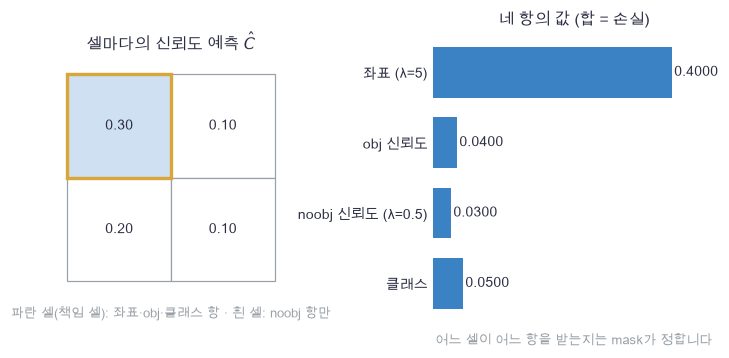

In [22]:
plot_loss_terms(loss_pred[0, ..., 4], loss_obj[0], loss_names, loss_terms_hand)

🔍 **확인** · 왼쪽 표는 셀 네 개의 신뢰도 예측입니다. 파란 셀(책임 셀) 하나만 좌표·obj·클래스 항을 받고, 흰 셀 셋은 noobj 항만 받습니다.
오른쪽 막대에서 좌표 항이 가장 큽니다. 어긋난 정도는 0.04 + 0.04로 작지만 $\lambda_{coord}=5$가 곱해졌기 때문입니다. 반대로 noobj 항은 셀이 셋이나 되는데도 $\lambda_{noobj}=0.5$ 때문에 가장 작습니다.
이 두 가중치가 "상자를 맞히는 일"과 "빈 곳을 비었다고 말하는 일" 사이의 저울입니다. 아래 구현은 네 항과 그 미분을 함께 돌려줍니다.

In [23]:
def yolo_loss(pred, target, obj, lam_coord=5.0, lam_noobj=0.5):
    """YOLO 손실과 pred 미분. 네 묶음의 제곱합을 셀에서 더하고 캔버스 축에서만 평균냅니다.
    pred, target: (N, S, S, 5+K) (target[..., 4]는 이미 고정된 신뢰도 타깃), obj: (N, S, S) bool
    → (loss: 숫자, dpred: pred와 같은 모양, terms: 네 항의 사전)."""
    N = len(pred)
    mask = obj[..., None]                                                  # (N, S, S, 1): 칸 축에 브로드캐스팅할 mask
    d_xy = pred[..., 0:2] - target[..., 0:2]                               # (N, S, S, 2): 중심 오차
    d_wh = np.sqrt(pred[..., 2:4]) - np.sqrt(target[..., 2:4])             # (N, S, S, 2): √ 안에서 뺀 크기 오차
    d_conf = pred[..., 4] - target[..., 4]                                 # (N, S, S): 신뢰도 오차
    d_cls = pred[..., 5:] - target[..., 5:]                                # (N, S, S, K): 클래스 오차
    terms = {"좌표": lam_coord * np.sum(obj * (np.sum(d_xy ** 2, -1) + np.sum(d_wh ** 2, -1))) / N,      # 네 묶음. 이름은 그림·기록의 열 이름이 됩니다
             "obj 신뢰도": np.sum(obj * d_conf ** 2) / N,
             "noobj 신뢰도": lam_noobj * np.sum(~obj * pred[..., 4] ** 2) / N,
             "클래스": np.sum(obj * np.sum(d_cls ** 2, -1)) / N}
    dpred = np.zeros_like(pred)
    dpred[..., 0:2] = 2 * lam_coord * mask * d_xy / N                                  # 2λ 1^obj (t̂ − t)
    dpred[..., 2:4] = lam_coord * mask * d_wh / np.sqrt(pred[..., 2:4]) / N            # 2λ 1^obj (√t̂ − √t) · 1/(2√t̂)
    dpred[..., 4] = 2 * (obj * d_conf + lam_noobj * ~obj * pred[..., 4]) / N
    dpred[..., 5:] = 2 * mask * d_cls / N
    return sum(terms.values()), dpred, terms

In [24]:
# 쓰는 것: loss_pred, loss_target, loss_obj, loss_terms_hand (3절 손계산 셀)
hand_loss, hand_dpred, hand_terms = yolo_loss(loss_pred, loss_target, loss_obj)
np.testing.assert_allclose(list(hand_terms.values()), loss_terms_hand)      # 검산: 네 항이 손계산과 같음
np.testing.assert_allclose(hand_loss, 0.52)                                 # 검산: 0.4 + 0.04 + 0.03 + 0.05
np.testing.assert_allclose(hand_dpred[0, 0, 0, 0], 2.0)                     # 검산: 2·5·(0.7 − 0.5)/1
np.testing.assert_allclose(hand_dpred[0, 0, 0, 2], 5 * (0.3 - 0.5) / 0.3)   # 검산: λ(√ŵ − √w)/√ŵ = 5·(−0.2)/0.3
np.testing.assert_allclose(hand_dpred[0, 0, 1, 4], 2 * 0.5 * 0.1)           # 검산: 빈 셀은 2·λ_noobj·Ĉ
print("손실", hand_loss, "\n네 항", {k: round(v, 4) for k, v in hand_terms.items()})
print("책임 셀의 기울기 7칸", hand_dpred[0, 0, 0])

손실 0.5199999999999999 
네 항 {'좌표': np.float64(0.4), 'obj 신뢰도': np.float64(0.04), 'noobj 신뢰도': np.float64(0.03), '클래스': np.float64(0.05)}
책임 셀의 기울기 7칸 [ 2.      0.     -3.3333  0.     -0.4    -0.4     0.2   ]


🔍 **확인** · 네 항과 합계 0.52가 손계산과 같습니다. 책임 셀의 기울기 7칸을 보면 $t_y$와 $t_h$는 정확히 맞혔으므로 0이고, $t_w$ 칸만 $\sqrt{\ }$ 때문에 $-3.33$으로 큽니다. 예측 너비 0.09가 정답 0.25보다 많이 작은데, $\sqrt{\ }$가 작은 값 근처에서 가파르기 때문입니다.
빈 셀의 신뢰도 기울기는 $2\lambda_{noobj}\hat C=0.1$로, 그냥 "0 쪽으로 밀어라"입니다.

아래는 신뢰도 타깃을 IoU로 정하는 함수입니다. IoU를 계산해 타깃 배열에 **넣어 둔 뒤** 손실을 부르므로, `yolo_loss` 입장에서 신뢰도 타깃은 그냥 상수입니다.

In [25]:
def set_conf_target(pred, target, obj):
    """신뢰도 타깃을 "예측 상자와 정답 상자의 IoU"로 바꾼 새 타깃. 이 IoU는 상수로 얼려 미분하지 않습니다(13번 5절).
    pred, target: (N, S, S, 5+K), obj: (N, S, S) bool → target과 같은 모양의 새 배열."""
    # 쓰는 것: box_iou (1절) · decode_boxes (2절)
    iou = box_iou(decode_boxes(pred), decode_boxes(target))      # (N, S, S): 같은 셀끼리 짝지은 IoU
    fixed = target.copy()
    fixed[..., 4] = np.where(obj, iou, 0.0)                      # 빈 셀의 신뢰도 타깃은 0
    return fixed

In [26]:
# 쓰는 것: S (📎 데이터 셀) · target_train, obj_train (2절 검산 셀) · set_conf_target, yolo_loss (3절) · numerical_gradient, rel_error (준비 셀)
rng = np.random.default_rng(1802)                                  # 이 노트북의 검산용 난수 생성기. 4절도 이어 씁니다
check_pred = rng.uniform(0.05, 0.95, size=(2, S, S, 15))           # (2, 4, 4, 15): 학습 전 출력이라 치고 아무 값이나
check_target = set_conf_target(check_pred, target_train[:2], obj_train[:2])
check_loss, check_dpred, _ = yolo_loss(check_pred, check_target, obj_train[:2])


def loss_scalar():
    """검사기용: 고정된 타깃에서의 손실 하나. numerical_gradient가 check_pred를 흔들며 다시 부릅니다."""
    return yolo_loss(check_pred, check_target, obj_train[:2])[0]


loss_error = rel_error(check_dpred, numerical_gradient(loss_scalar, check_pred))   # 중심차분과의 상대오차
assert loss_error < 1e-6, f"손실 미분의 상대오차 {loss_error:.2e}는 1e−6 아래여야 합니다"
print("YOLO 손실 미분의 상대오차:", loss_error)

YOLO 손실 미분의 상대오차: 2.7524119796047545e-10


In [27]:
# 쓰는 것: check_pred, check_target, check_loss, loss_error (3절 검산 셀) · target_train, obj_train (2절 검산 셀) · set_conf_target, yolo_loss (3절)
def live_loss_scalar():
    """검사기용: 흔들 때마다 IoU 타깃을 다시 계산하는 손실. 얼리지 않았다면 이 값이 진짜 손실입니다."""
    return yolo_loss(check_pred, set_conf_target(check_pred, target_train[:2], obj_train[:2]), obj_train[:2])[0]


live_error = rel_error(check_dpred, numerical_gradient(live_loss_scalar, check_pred))
assert live_error > 0.01, "IoU 타깃을 얼리지 않으면 중심차분이 우리 식과 눈에 띄게 달라야 합니다"
doubled = yolo_loss(check_pred, check_target, obj_train[:2], lam_noobj=1.0)[2]      # λ_noobj 만 두 배
base = yolo_loss(check_pred, check_target, obj_train[:2])[2]
np.testing.assert_allclose(doubled["noobj 신뢰도"], 2 * base["noobj 신뢰도"])       # 검산: noobj 항만 두 배 (14번 2절)
np.testing.assert_allclose(doubled["좌표"], base["좌표"])                           # 검산: 다른 항은 그대로
print("IoU 타깃을 얼리지 않았을 때의 상대오차:", live_error)
print("λ_noobj 를 0.5 → 1.0 으로 바꾼 뒤의 네 항\n", {k: round(v, 4) for k, v in doubled.items()})

IoU 타깃을 얼리지 않았을 때의 상대오차: 0.1026393783472654
λ_noobj 를 0.5 → 1.0 으로 바꾼 뒤의 네 항
 {'좌표': np.float64(3.9038), 'obj 신뢰도': np.float64(0.2374), 'noobj 신뢰도': np.float64(4.7709), '클래스': np.float64(6.8959)}


🔍 **확인** · 우리가 손으로 유도한 미분이 중심차분과 $10^{-6}$ 아래에서 같습니다. mask와 신뢰도 타깃을 상수로 둔 식이 맞다는 뜻입니다.
두 번째 숫자가 이 절의 핵심입니다. 흔들 때마다 IoU 타깃을 **다시 계산**하면 같은 미분이 10% 넘게 어긋납니다. 예측 상자를 조금 옮기면 IoU도 따라 변해서 경로가 하나 더 생기기 때문입니다. 우리는 그 경로를 일부러 끊었습니다. 끊지 않으면 "상자를 정답에서 멀리 옮겨 IoU 타깃을 낮추고, 낮아진 타깃에 신뢰도를 맞추는" 쉬운 길이 열립니다.
$\lambda_{noobj}$를 두 배로 하면 noobj 항만 정확히 두 배가 되고 나머지 세 항은 그대로입니다. 가중치가 항 하나만 키운다는 14번 2절의 성질입니다.

### ✏️ 연습 3 · √ 항의 기울기

너비·높이 항 $\lambda_{coord}(\sqrt{\hat w}-\sqrt{w})^2$를 $\hat w$로 미분한 한 줄을 채우세요(책임 셀만 다루므로 mask는 없습니다). $\sqrt{\ }$의 도함수 $1/(2\sqrt{\hat w})$가 붙어 2와 약분되는 자리입니다. 검사는 손계산 $-10/3$과 중심차분으로 합니다.

In [28]:

def exercise_sqrt_gradient(pred_wh, target_wh, lam_coord=5.0):
    """연습 3: 좌표 묶음의 크기 항 λ(√ŵ − √w)² 를 ŵ 로 미분. pred_wh, target_wh: (..., 2) 양수 → (..., 2)."""
    assert np.all(pred_wh > 0), "√ 을 미분하려면 예측 너비·높이가 양수여야 합니다"
    d_wh = np.sqrt(pred_wh) - np.sqrt(target_wh)          # (..., 2): √ 안에서 뺀 오차
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: grad = 2λ·d_wh·(1/(2√ŵ)) 를 약분한 한 줄 (모양은 pred_wh 와 같음)
    ### 힌트: 3절 yolo_loss 의 dpred[..., 2:4] 줄에서 mask 와 1/N 을 뺀 것입니다. 2 와 1/2 가 약분됩니다.
    raise NotImplementedError
    return grad


In [29]:

def check_sqrt_gradient(candidate):
    """손계산 −10/3 과 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: numerical_gradient (준비 셀)
    example_pred = np.array([0.09, 0.25])                         # (2,): 예측 너비·높이
    example_target = np.array([0.25, 0.25])                       # (2,): 정답 너비·높이
    actual = candidate(example_pred, example_target)
    assert np.shape(actual) == (2,), f"기울기는 입력과 같은 (2,)여야 하는데 {np.shape(actual)}입니다"
    np.testing.assert_allclose(actual, [5 * (0.3 - 0.5) / 0.3, 0.0])   # 검산: 손계산 5·(√0.09 − √0.25)/√0.09 = −10/3, 맞힌 쪽은 0
    probe = np.array([0.16, 0.49])                                # (2,): 중심차분용 다른 값

    def term_scalar():
        """검사기용: λ Σ (√ŵ − √w)² 하나. numerical_gradient 가 probe 를 흔들며 다시 부릅니다."""
        return float(5.0 * np.sum((np.sqrt(probe) - np.sqrt(example_target)) ** 2))

    np.testing.assert_allclose(candidate(probe, example_target), numerical_gradient(term_scalar, probe), rtol=1e-6)   # 검산: 중심차분
    print("√ 항의 기울기: 손계산·중심차분과 일치합니다.")


run_check(check_sqrt_gradient, exercise_sqrt_gradient, hint="grad = lam_coord * d_wh / np.sqrt(pred_wh)")


☐ exercise_sqrt_gradient: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: grad = lam_coord * d_wh / np.sqrt(pred_wh)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
grad = lam_coord * d_wh / np.sqrt(pred_wh)
```

</details>

## 🔑 4. 백본이 만든 4×4 특성 맵의 칸 하나가 격자 셀 하나

**이 절에서 가져갈 것:** 합성곱·ReLU·풀링을 세 번 쌓으면 32×32가 4×4로 줄어듭니다. 이 4×4가 곧 격자 $S\times S$이므로, 특성 맵의 칸마다 같은 선형층을 적용해 15개를 내면 출력이 바로 $(N,4,4,15)$입니다. 앞 5칸은 0–1 값이어야 하므로 sigmoid를 씌웁니다.

05번에서 풀링은 "크기를 반으로 줄이면서 어느 자리에 무엇이 있는지는 남긴다"였습니다. 세 번 줄이면 32 → 16 → 8 → 4이고, 마지막 4×4의 한 칸은 원래 이미지의 8×8 구역에 **자리를 맞춘** 값입니다(세 번 반으로 줄인 자리). 3×3 합성곱이 옆으로 번지므로 한 칸이 실제로 보는 범위는 그보다 넓은 22×22이지만, **자리**는 2절에서 나눈 셀과 정확히 같습니다.

> **용어**
>
> - **특성 맵(feature map)**: 합성곱이 낸 `(채널, 세로, 가로)` 배열. 칸 하나가 "원본의 그 자리 근처에 이 커널의 무늬가 있나"를 적은 숫자입니다(05번 1절). 여기서는 백본의 마지막 출력 `(N, 32, 4, 4)`입니다.
> - **백본(backbone)**: 이미지를 특성 맵으로 바꾸는 앞부분. 여기서는 conv → ReLU → 풀링 세 묶음입니다.
> - **head**: 특성 맵을 우리가 원하는 답의 모양으로 바꾸는 마지막 층. 여기서는 셀마다의 선형층 하나입니다.
> - **He 초기화(He initialization)**: ReLU 앞 가중치의 표준편차를 $\sqrt{2/\text{입력 수}}$로 두는 것(04번 9절). 합성곱은 입력 수가 채널 × 3 × 3입니다.
> - **sigmoid** $\sigma(z)=1/(1+e^{-z})$: 실수를 0과 1 사이로 누르는 함수(02번 7절). 셀 안 상대 좌표·너비·높이·신뢰도가 모두 0–1이라 앞 5칸에 씌웁니다.

모양의 흐름입니다. 괄호 안이 그 단계의 텐서 모양입니다.

`(N,1,32,32)` → conv 8 → ReLU → pool → `(N,8,16,16)` → conv 16 → ReLU → pool → `(N,16,8,8)` → conv 32 → ReLU → pool → `(N,32,4,4)`
→ 채널 축을 뒤로 → `(N,4,4,32)` → 선형층 $W\in\mathbb R^{32\times15}$ → `(N,4,4,15)` → 앞 5칸에 sigmoid → $\hat y$.

head의 식은 셀 $(i,j)$마다 같습니다. $f_{n,i,j}\in\mathbb R^{32}$가 그 칸의 특징 벡터이면
$$\hat y_{n,i,j}=[\,\sigma(f_{n,i,j}W+b)_{0:5},\ (f_{n,i,j}W+b)_{5:15}\,].$$

같은 $W$를 셀 16개에 모두 쓰므로 05번의 **가중치 공유**가 head에도 적용된 셈입니다. backward도 05번의 층들을 거꾸로 부르기만 하면 되고, sigmoid를 지나는 자리에서 $\sigma'(z)=\sigma(z)(1-\sigma(z))$를 곱합니다.

> **코드**
>
> - `A.transpose(0, 2, 3, 1)`: `(N, C, S, S)`(여기서 `C`는 채널 수)의 채널 축을 맨 뒤로 보내 `(N, S, S, C)`로. 이러면 마지막 축이 특징 벡터라 `@ W` 한 번으로 셀마다 선형층이 됩니다.
> - `np.tensordot(feats, draw, axes=([0, 1, 2], [0, 1, 2]))`: 앞 세 축(캔버스·행·열)을 함께 더해 `(C, 15)`인 `dW`를 만듭니다. 03번 선형층의 `X.T @ dZ`를 축이 여러 개인 경우로 넓힌 것입니다.
> - `p[f"K{i}"]`: 파라미터 사전의 키를 번호로 만듭니다. `f"K{1}"`은 `"K1"`입니다.
> - `* (Z > 0)`: ReLU의 도함수. 양수였던 자리만 1입니다(03번 3절의 활성화 표, 곱하는 자리는 5절).

In [30]:
# 쓰는 것: N_CLASSES, S (📎 데이터 셀)
detector_blocks = [("입력 캔버스", "(N, 1, 32, 32)"), ("conv 3×3, 8", "(N, 8, 32, 32)"), ("ReLU · max pool", "(N, 8, 16, 16)"),
                   ("conv 3×3, 16", "(N, 16, 16, 16)"), ("ReLU · max pool", "(N, 16, 8, 8)"), ("conv 3×3, 32", "(N, 32, 8, 8)"),
                   ("ReLU · max pool", "(N, 32, 4, 4)"), ("셀마다 선형 32→15", "(N, 4, 4, 15)"), ("앞 5칸 sigmoid", "(N, 4, 4, 15)")]
n_conv = 8 * (1 * 9) + 8 + 16 * (8 * 9) + 16 + 32 * (16 * 9) + 32      # 커널 수 × (입력 채널 × 3 × 3) + 편향
n_head = 32 * (5 + N_CLASSES) + (5 + N_CLASSES)                        # 셀마다 공유하는 선형층 (32, 15) + (15,)
n_head_flat = 32 * S * S * (S * S * (5 + N_CLASSES)) + S * S * (5 + N_CLASSES)   # 펼쳐서 완전 연결로 만들었을 때
print("파라미터: 백본", n_conv, "+ head", n_head, "=", n_conv + n_head)
print("head 를 펼쳐서 완전 연결로 두면", n_head_flat, "개")

파라미터: 백본 5888 + head 495 = 6383
head 를 펼쳐서 완전 연결로 두면 123120 개


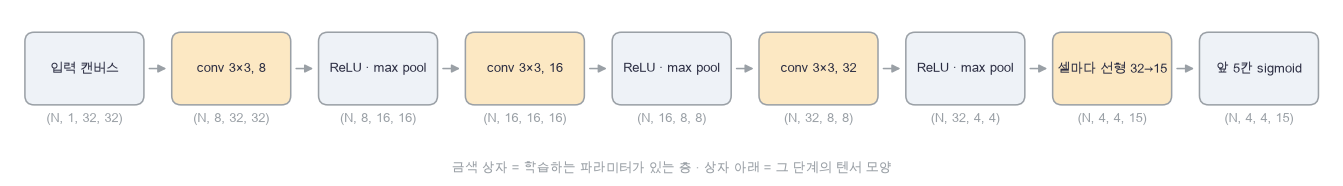

In [31]:
plot_detector_blocks(detector_blocks, param_blocks=(1, 3, 5, 7))

🔍 **확인** · 금색 상자 네 개(합성곱 셋과 선형층 하나)에만 파라미터가 있고, ReLU·풀링·sigmoid는 값이나 모양만 바꿉니다. 전체 6,383개뿐입니다.
head를 셀마다 공유하지 않고 4×4×32를 통째로 펼쳐 완전 연결로 만들면 123,120개가 필요합니다. YOLO v1 원논문은 실제로 그 방식이었지만, 이 노트북의 작은 캔버스 데이터에서는 그 head가 학습 캔버스를 통째로 외워 버려 검증 성능이 크게 떨어집니다. 그래서 여기서는 05번의 가중치 공유를 head에도 적용했습니다. 이후 버전의 YOLO도 합성곱 head를 씁니다.

아래 네 셀은 05번 2·3·4절의 합성곱·풀링을 이 노트북에 맞게(stride 1, 2×2 최대 풀링) 짧게 다시 정의한 것입니다. 식은 05번과 같습니다.

In [32]:
def conv_forward(X, K, b, padding=1):
    """05번 2절의 패치 행렬 합성곱(stride 1). 모든 창을 행으로 쌓은 P 에 대해 Y_rows = P K_flatᵀ + b.
    X: (N, C, H, W), K: (F, C, kh, kw), b: (F,) → (Y: (N, F, oh, ow), cache: backward 용)."""
    N, C, H, W = X.shape
    F, _, kh, kw = K.shape
    Xp = np.pad(X, ((0, 0), (0, 0), (padding, padding), (padding, padding)))   # 세로·가로에만 0을 두름
    oh, ow = H + 2 * padding - kh + 1, W + 2 * padding - kw + 1                # stride 1 의 출력 크기
    patches = np.empty((N, oh, ow, C, kh, kw))
    for i in range(oh):
        for j in range(ow):
            patches[:, i, j] = Xp[:, :, i:i + kh, j:j + kw]                    # 모든 캔버스의 (i, j) 창
    P = patches.reshape(N * oh * ow, -1)                                       # (N·oh·ow, C·kh·kw): 패치 행렬
    rows = P @ K.reshape(F, -1).T + b
    return rows.reshape(N, oh, ow, F).transpose(0, 3, 1, 2), (X.shape, K, P, padding)

In [33]:
def conv_backward(dY, cache):
    """05번 3절의 합성곱 backward: dK = Gᵀ P, db = Σ_rows G, dP = G K_flat, 그리고 겹친 자리에 **더해** dX.
    dY: (N, F, oh, ow), cache: conv_forward 의 것 → (dX, dK, db)."""
    shape, K, P, padding = cache
    N, C, H, W = shape
    F, _, kh, kw = K.shape
    _, _, oh, ow = dY.shape
    G = dY.transpose(0, 2, 3, 1).reshape(N * oh * ow, F)                       # (N·oh·ow, F): 상류 기울기를 행으로
    dK = (G.T @ P).reshape(K.shape)
    db = G.sum(axis=0)
    dpatches = (G @ K.reshape(F, -1)).reshape(N, oh, ow, C, kh, kw)
    dXp = np.zeros((N, C, H + 2 * padding, W + 2 * padding))
    for i in range(oh):
        for j in range(ow):
            dXp[:, :, i:i + kh, j:j + kw] += dpatches[:, i, j]                 # 겹친 칸은 더함 (= 가 아니라 +=)
    return dXp[:, :, padding:padding + H, padding:padding + W], dK, db

In [34]:
def pool_forward(X):
    """05번 4절의 2×2 최대 풀링 forward. 구역마다 최댓값 하나만 남기고 최댓값 번호를 캐시에 둡니다.
    X: (N, C, H, W), H·W 짝수 → (Y: (N, C, H/2, W/2), cache)."""
    N, C, H, W = X.shape
    assert H % 2 == 0, "높이가 짝수여야 2×2 구역으로 나뉩니다"
    assert W % 2 == 0, "너비가 짝수여야 2×2 구역으로 나뉩니다"
    flat = X.reshape(N, C, H // 2, 2, W // 2, 2).transpose(0, 1, 2, 4, 3, 5).reshape(N, C, H // 2, W // 2, 4)
    indices = flat.argmax(axis=-1)                    # (N, C, H/2, W/2): 구역 안 최댓값 번호 0–3
    return flat.max(axis=-1), (X.shape, indices)


def pool_backward(dY, cache):
    """05번 4절의 2×2 최대 풀링 backward: 최댓값이 있던 칸 하나에만 기울기를 보냅니다.
    dY: (N, C, H/2, W/2), cache: pool_forward 의 것 → dX: (N, C, H, W)."""
    shape, indices = cache
    N, C, H, W = shape
    dflat = dY[..., None] * (np.arange(4) == indices[..., None])   # (…, 4): 최댓값 자리만 남김
    return dflat.reshape(N, C, H // 2, W // 2, 2, 2).transpose(0, 1, 2, 4, 3, 5).reshape(shape)

In [35]:
def init_detector(seed=1803, filters=(8, 16, 32)):
    """검출기 파라미터 사전. 합성곱은 He 초기화(04번 9절) √(2/입력 수), head 는 √(1/채널 수).
    seed: 시드, filters: 층마다의 커널 수 → {"K1", "c1", …, "W", "b"}."""
    # 쓰는 것: N_CLASSES (📎 데이터 셀)
    rng_init = np.random.default_rng(seed)
    params, channels = {}, 1
    for i, f in enumerate(filters):
        params[f"K{i + 1}"] = rng_init.normal(size=(f, channels, 3, 3)) * np.sqrt(2 / (channels * 9))
        params[f"c{i + 1}"] = np.zeros(f)
        channels = f
    params["W"] = rng_init.normal(size=(channels, 5 + N_CLASSES)) * np.sqrt(1 / channels)
    params["b"] = np.zeros(5 + N_CLASSES)
    return params

In [36]:
def detector_forward(X, params):
    """백본 세 묶음 뒤 셀마다의 선형층, 앞 5칸에 sigmoid. X: (N, 1, 32, 32) → (pred: (N, S, S, 15), cache)."""
    # 쓰는 것: conv_forward, pool_forward (4절)
    A, caches = X, []
    for i in (1, 2, 3):
        Z, conv_cache = conv_forward(A, params[f"K{i}"], params[f"c{i}"])
        A, pool_cache = pool_forward(np.maximum(Z, 0))              # ReLU 뒤 2×2 최대 풀링
        caches.append((Z, conv_cache, pool_cache))
    feats = A.transpose(0, 2, 3, 1)                                 # (N, S, S, 32): 셀마다의 특징 벡터
    raw = feats @ params["W"] + params["b"]                         # (N, S, S, 15): 셀마다 같은 선형층
    pred = raw.copy()
    pred[..., :5] = 1 / (1 + np.exp(-raw[..., :5]))                 # 앞 5칸만 0–1 로 (sigmoid)
    return pred, (caches, feats, pred)

In [37]:
def detector_backward(dpred, cache, params):
    """forward 의 순서를 거꾸로: sigmoid 도함수 → head → 풀링 → ReLU → 합성곱.
    dpred: (N, S, S, 15), cache: detector_forward 의 것 → (dX, grads: params 와 같은 키의 사전)."""
    # 쓰는 것: conv_backward, pool_backward (4절)
    caches, feats, pred = cache
    draw = dpred.copy()
    draw[..., :5] = dpred[..., :5] * pred[..., :5] * (1 - pred[..., :5])        # σ'(z) = σ(1 − σ)
    grads = {"W": np.tensordot(feats, draw, axes=([0, 1, 2], [0, 1, 2])), "b": draw.sum(axis=(0, 1, 2))}
    dA = (draw @ params["W"].T).transpose(0, 3, 1, 2)                           # (N, 32, S, S): 채널 축을 앞으로 되돌림
    for i in (3, 2, 1):
        Z, conv_cache, pool_cache = caches[i - 1]
        dZ = pool_backward(dA, pool_cache) * (Z > 0)                            # 풀링 backward 뒤 ReLU 도함수
        dA, grads[f"K{i}"], grads[f"c{i}"] = conv_backward(dZ, conv_cache)
    return dA, grads

In [38]:
# 쓰는 것: rng (3절 검산 셀) · init_detector, detector_forward, detector_backward (4절) · numerical_gradient, rel_error (준비 셀)
tiny_params = init_detector(seed=1899, filters=(2, 3, 4))       # 작은 모델이라야 중심차분이 빨리 끝납니다
tiny_X = rng.normal(size=(1, 1, 16, 16))                        # (1, 1, 16, 16): 세 번 줄이면 2×2 격자
tiny_pred, tiny_cache = detector_forward(tiny_X, tiny_params)
tiny_G = rng.normal(size=tiny_pred.shape)                       # 임의의 상류 기울기
_, tiny_grads = detector_backward(tiny_G, tiny_cache, tiny_params)


def tiny_scalar():
    """검사기용: 스칼라 L = Σ pred ⊙ G. 이러면 dL/dpred = G 라서 backward 결과를 중심차분과 비교할 수 있습니다."""
    return float(np.sum(detector_forward(tiny_X, tiny_params)[0] * tiny_G))


tiny_errors = {key: rel_error(tiny_grads[key], numerical_gradient(tiny_scalar, value)) for key, value in tiny_params.items()}
assert tiny_pred.shape == (1, 2, 2, 15), "16×16 입력은 2×2 격자가 되어야 합니다"
assert max(tiny_errors.values()) < 2e-6, "모든 파라미터 기울기의 상대오차가 2e−6 아래여야 합니다"
print("작은 검출기 전체 미분 최대 상대오차:", max(tiny_errors.values()))
print("파라미터별", {key: f"{value:.1e}" for key, value in tiny_errors.items()})

작은 검출기 전체 미분 최대 상대오차: 2.783798272303067e-09
파라미터별 {'K1': '1.0e-09', 'c1': '2.7e-09', 'K2': '4.5e-10', 'c2': '1.2e-09', 'K3': '2.6e-10', 'c3': '2.8e-09', 'W': '2.7e-10', 'b': '4.8e-10'}


🔍 **확인** · 커널 셋·편향 셋·head의 $W,b$ 여덟 배열 모두 중심차분과 $2\times10^{-6}$ 아래에서 같습니다. 16×16 입력이 2×2 격자가 되는 것도 확인했습니다. 격자 크기는 입력 크기를 세 번 반으로 나눈 값이라 코드를 고치지 않고 캔버스 크기만 바꿔도 따라갑니다.
학습이 잘 되는 것만으로 미분이 맞다고 보지 않습니다. 여기서 먼저 확인하고 학습에 들어갑니다.

아래는 04번 6절의 Adam과 미니배치 루프입니다. 스텝마다 forward → IoU 타깃 고정 → 손실 → backward → 갱신 순서입니다.

> **코드**
>
> - `{key: (np.zeros_like(v), np.zeros_like(v)) for key, v in params.items()}`: 파라미터마다 Adam 상태 (m, v)를 0으로 만든 사전.
> - `rng_train.choice(len(canvas_X_train), 32, replace=False)`: 2,000장 중 32장을 겹치지 않게 뽑은 번호. 이번 스텝의 미니배치입니다(01b번 3절).

In [39]:
def adam_update(params, grads, state, step, lr=3e-3):
    """Adam 갱신(04번 6절)을 파라미터 사전의 모든 배열에. params 를 제자리에서 바꾸고 state 의 (m, v)를 갱신합니다.
    params, grads: 같은 키의 사전, state: 키 → (m, v), step: 1부터 세는 스텝 수."""
    for key in params:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                                # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2                       # 2차 모멘트
        params[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)
        state[key] = (m, v)

In [40]:
def train_detector(lam_noobj=0.5, steps=700, seed=1804):
    """미니배치 32장으로 Adam 학습. 스텝마다 forward → IoU 타깃 고정 → 손실 → backward → 갱신입니다.
    lam_noobj: noobj 항 가중치, steps: 스텝 수, seed: 미니배치 난수 → (params: 파라미터 사전, history: 50스텝 평균 기록)."""
    # 쓰는 것: canvas_X_train (📎 데이터 셀) · target_train, obj_train (2절 검산 셀) · set_conf_target, yolo_loss (3절) · init_detector, detector_forward, detector_backward, adam_update (4절)
    params = init_detector()
    state = {key: (np.zeros_like(v), np.zeros_like(v)) for key, v in params.items()}
    rng_batch = np.random.default_rng(seed)
    history, running = {"step": []}, {}
    for step in range(1, steps + 1):
        batch = rng_batch.choice(len(canvas_X_train), 32, replace=False)              # 1. 미니배치 32장
        pred, cache = detector_forward(canvas_X_train[batch], params)                 # 2. forward
        batch_target = set_conf_target(pred, target_train[batch], obj_train[batch])   # 3. IoU 를 신뢰도 타깃으로 얼림
        _, dpred, terms = yolo_loss(pred, batch_target, obj_train[batch], lam_noobj=lam_noobj)
        _, grads = detector_backward(dpred, cache, params)                            # 4. backward
        adam_update(params, grads, state, step)                                       # 5. 갱신 (step 은 1부터)
        for key, value in terms.items():
            running.setdefault(key, []).append(value)
        if step % 50 == 0:                                                            # 6. 50스텝마다 평균을 기록
            history["step"].append(step)
            for key, values in running.items():
                history.setdefault(key, []).append(float(np.mean(values)))
            running = {}
    return params, history

In [41]:
# 쓰는 것: train_detector (4절)
detector_params, history = train_detector()
term_keys = [key for key in history if key != "step"]
print("네 항 처음", {key: round(history[key][0], 4) for key in term_keys})
print("네 항 마지막", {key: round(history[key][-1], 4) for key in term_keys})
assert history["좌표"][-1] < history["좌표"][0], "좌표 항이 줄어야 합니다"
assert history["클래스"][-1] < history["클래스"][0], "클래스 항이 줄어야 합니다"

네 항 처음 {'좌표': 1.8561, 'obj 신뢰도': 0.0851, 'noobj 신뢰도': 1.1238, '클래스': 3.0161}
네 항 마지막 {'좌표': 0.178, 'obj 신뢰도': 0.0998, 'noobj 신뢰도': 0.078, '클래스': 1.1114}


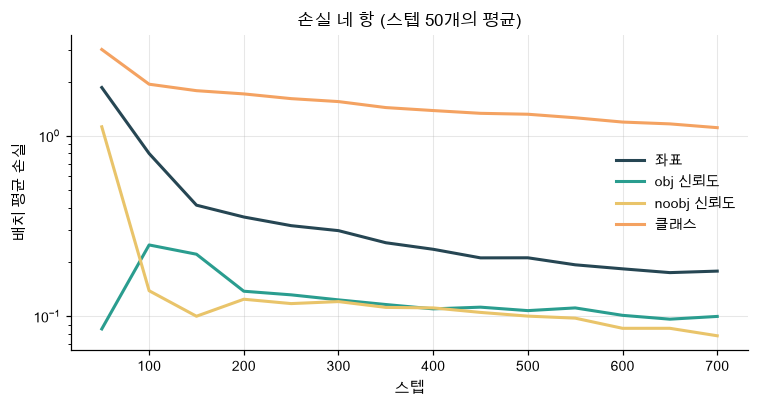

In [42]:
plot_curves(history["step"], {key: history[key] for key in term_keys},
            title="손실 네 항 (스텝 50개의 평균)", ylabel="배치 평균 손실", logy=True)

In [43]:
# 쓰는 것: canvas_X_valid, canvas_labels_valid (📎 데이터 셀) · target_valid, obj_valid (2절 검산 셀) · detector_params (4절 학습 셀) · detector_forward, decode_boxes, box_iou
valid_pred, _ = detector_forward(canvas_X_valid, detector_params)     # (200, 4, 4, 15)
valid_boxes = decode_boxes(valid_pred)                                # (200, 4, 4, 4): 캔버스 비율 상자
valid_class = valid_pred[..., 5:].argmax(axis=-1)                     # (200, 4, 4): 셀마다 가장 큰 클래스 칸
valid_iou = box_iou(valid_boxes, decode_boxes(target_valid))[obj_valid]            # (물체 수,): 책임 셀의 상자 정확도
valid_class_correct = np.mean(valid_class[obj_valid] == target_valid[..., 5:].argmax(axis=-1)[obj_valid])
assert valid_iou.mean() > 0.5, "책임 셀의 상자가 정답과 평균 IoU 0.5는 넘어야 합니다"
assert valid_class_correct > 0.5, "책임 셀의 클래스 정답률이 절반은 넘어야 합니다"
print(f"검증 책임 셀: 상자 IoU 평균 {valid_iou.mean():.3f} · 클래스 정답률 {valid_class_correct:.1%} (n={len(valid_iou)})")
print(f"신뢰도 평균: 책임 셀 {valid_pred[..., 4][obj_valid].mean():.3f} · 빈 셀 {valid_pred[..., 4][~obj_valid].mean():.3f}")

검증 책임 셀: 상자 IoU 평균 0.716 · 클래스 정답률 71.8% (n=412)
신뢰도 평균: 책임 셀 0.622 · 빈 셀 0.055


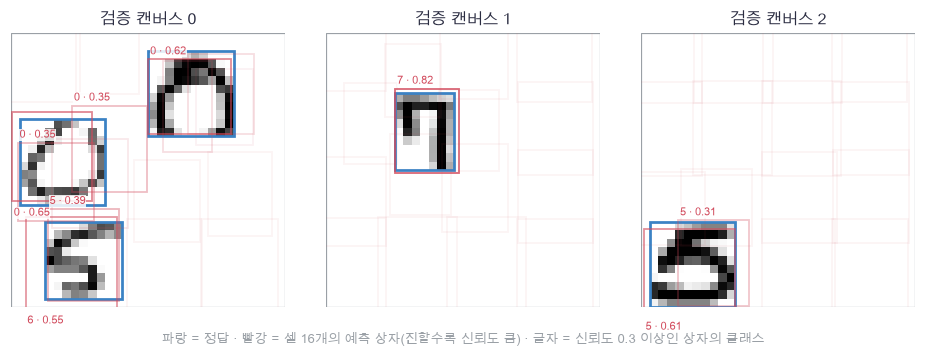

In [44]:
plot_detections([canvas_X_valid[k, 0] for k in range(3)], [valid_boxes[k] for k in range(3)],
                [valid_pred[k, ..., 4] for k in range(3)], [valid_class[k] for k in range(3)],
                [canvas_labels_valid[k][canvas_labels_valid[k, :, 0] >= 0][:, 1:] for k in range(3)],
                [canvas_labels_valid[k][canvas_labels_valid[k, :, 0] >= 0][:, 0] for k in range(3)],
                threshold=0.3, titles=[f"검증 캔버스 {k}" for k in range(3)])

🔍 **확인** · noobj 항은 "0이라고 말하기"라서 금방 작아지고, 클래스 항은 숫자 10개를 구별해야 해서 가장 느립니다.
obj 신뢰도 항만 처음에 오히려 커집니다. 학습 초기에는 상자가 엉망이라 IoU 타깃이 0에 가깝고 신뢰도도 noobj 항에 눌려 0에 가까워 둘이 우연히 맞습니다. 상자가 좋아져 IoU 타깃이 0.7 근처까지 올라가면 신뢰도가 그 값을 따라잡아야 하므로 항이 잠깐 커졌다가 다시 줄어듭니다.
그림에서 셀 16개가 각각 빨간 상자를 하나씩 내놓았고, 진하기가 신뢰도입니다. 숫자가 있는 자리 근처에서만 진하고 빈 셀의 상자는 거의 투명합니다. 글자가 붙은 상자(신뢰도 0.3 이상)를 보면 파란 정답 상자와 잘 포개집니다.
문제는 물체 하나에 진한 상자가 여러 개 붙는다는 점입니다. 옆 셀도 "여기 뭔가 있다"고 답하기 때문입니다. 5절에서 정리합니다.

📎 이 숫자는 **학습용 작은 문제의 성능**입니다. 캔버스는 이 노트북이 만든 것이고 숫자는 겹치지 않으며 클래스도 10개뿐입니다. COCO 같은 실제 검출 벤치마크의 점수로 읽지 마세요.

### ✏️ 연습 4 · 격자 출력 두 줄

백본이 낸 특성 맵 `A` `(N, C, S, S)`를 셀마다의 선형층에 넣어 `raw` `(N, S, S, 5+K)`를 만드는 두 줄을 채우세요. 채널 축을 맨 뒤로 보내면 마지막 축이 특징 벡터가 되어 `@ W` 한 번으로 끝납니다. 검사는 손계산 한 경우와 4절 `detector_forward`의 sigmoid 전 값으로 합니다.

In [45]:

def exercise_grid_head(A, W, b):
    """연습 4: 특성 맵의 칸마다 같은 선형층을 적용한 격자 출력. A: (N, C, S, S), W: (C, 5+K), b: (5+K,) → raw: (N, S, S, 5+K)."""
    assert A.shape[1] == W.shape[0], "특성 맵의 채널 수와 W 의 행 수가 같아야 합니다"
    assert A.shape[2] == A.shape[3], "이 연습은 정사각 격자만 다룹니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 채널 축을 맨 뒤로 보낸 feats (모양 (N, S, S, C)) 와, 선형층 feats @ W + b 인 raw (모양 (N, S, S, 5+K))
    ### 힌트: 4절 detector_forward 의 feats · raw 두 줄입니다. transpose 의 축 순서는 (0, 2, 3, 1) 입니다.
    raise NotImplementedError
    return raw


In [46]:

def check_grid_head(candidate):
    """(1, 2, 2, 2) 손계산 하나와 4절 tiny 모델의 sigmoid 전 값으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: tiny_params, tiny_cache, tiny_pred (4절 검산 셀)
    example_A = np.array([[[[1., 2.], [3., 4.]], [[0., 1.], [0., 2.]]]])      # (1, 2, 2, 2): 채널 2 · 격자 2×2
    example_W = np.array([[1., 0., 2.], [0., 1., 1.]])                        # (2, 3): 채널 2 → 출력 3
    example_b = np.array([0., 1., -1.])                                       # (3,)
    actual = candidate(example_A, example_W, example_b)
    assert actual.shape == (1, 2, 2, 3), f"격자 출력은 (N, S, S, 5+K) = (1, 2, 2, 3)이어야 하는데 {actual.shape}입니다"
    np.testing.assert_allclose(actual[0, 0, 0], [1., 1., 1.])                 # 검산: 셀 (0,0)의 특징 [1, 0] → [1, 0, 2] + b
    np.testing.assert_allclose(actual[0, 1, 1], [4., 3., 9.])                 # 검산: 셀 (1,1)의 특징 [4, 2] → [4, 2, 10] + b
    feats_ref = tiny_cache[1]                                                  # (1, 2, 2, 4): 4절이 캐시에 남긴 특징
    raw_ref = candidate(feats_ref.transpose(0, 3, 1, 2), tiny_params["W"], tiny_params["b"])
    np.testing.assert_allclose(raw_ref[..., 5:], tiny_pred[..., 5:])          # 검산: sigmoid 를 안 씌우는 뒤 10칸은 4절 출력과 같음
    print("격자 출력 두 줄: 손계산·detector_forward 와 일치합니다.")


run_check(check_grid_head, exercise_grid_head, hint="feats = A.transpose(0, 2, 3, 1) · raw = feats @ W + b")


☐ exercise_grid_head: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: feats = A.transpose(0, 2, 3, 1) · raw = feats @ W + b


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
feats = A.transpose(0, 2, 3, 1)
raw = feats @ W + b
```

</details>

## 🔑 5. 겹친 상자를 지우고, 남은 상자를 정답과 맞춰 점수를 냅니다

**이 절에서 가져갈 것:** 셀마다 나온 상자를 캔버스 좌표로 풀고 신뢰도가 낮은 것을 버린 뒤, **점수가 높은 것부터 남기면서 그것과 IoU가 임계값을 넘는 상자를 지웁니다**(NMS). 남은 상자를 점수 순으로 정답과 IoU 0.5 이상 매칭하면 precision–recall 곡선이 나오고, 그 아래 넓이가 AP입니다.

4절 그림에서 숫자 하나에 진한 상자가 두세 개 붙었습니다. 사람이 "여기 3이 있다"고 한 번만 말하듯, 모델의 답도 물체마다 하나로 줄여야 합니다. 겹친 상자 중 가장 자신 있는 것만 남기는 것이 가장 단순한 방법입니다.

> **용어**
>
> - **NMS(non-maximum suppression, 비최대 억제)**: 점수가 가장 높은 상자를 남기고, 그것과 많이 겹치는(IoU > 임계값) 상자를 지우는 것을 남은 상자가 없을 때까지 반복하는 절차. "최대가 아닌 것을 누른다"는 뜻입니다.
> - **greedy(탐욕적)**: 지금 가장 좋아 보이는 것을 먼저 고르고 되돌아보지 않는 방식. NMS는 점수 순서대로 한 번만 훑습니다.

절차를 그대로 옮기면 세 줄입니다. 살아 있는 후보를 `alive`로 두고, 점수 내림차순으로 $i$를 보면서

1. $i$가 이미 지워졌으면 건너뜁니다.
2. 아니면 $i$를 남깁니다.
3. $\mathrm{IoU}(i,\cdot)>\tau$인 후보를 모두 지웁니다(IoU가 $\tau$ 이하인 것만 남깁니다).

손계산: 상자 $A=(12,12,12,12)$ 점수 0.9, $B=(14,14,12,12)$ 점수 0.7, $C=(26,26,8,8)$ 점수 0.5입니다. $A$의 모서리는 가로·세로 모두 6–18, $B$는 8–20이므로 겹치는 부분은 $10\times10=100$, 합집합은 $144+144-100=188$이고 $\mathrm{IoU}(A,B)=100/188\approx0.53$입니다. $C$는 둘과 전혀 겹치지 않습니다. 임계값 0.5로 훑으면 $A$를 남기고 $B$를 지운 뒤 $C$를 남기므로 답은 $\{A, C\}$입니다.

> **코드**
>
> - `np.argsort(-scores)`: 점수에 −를 붙여 오름차순 정렬하면 큰 것부터의 순서가 나옵니다.
> - `alive &= iou[i] <= iou_threshold`: `&=`는 "둘 다 True 인 것만 남긴다"를 제자리에서 합니다. 많이 겹치는 상자는 오른쪽이 False 라 후보에서 빠집니다.
> - `np.where(mask)[0]`: True 인 자리의 번호 배열. 걸러 낸 뒤의 번호를 원래 번호로 되돌릴 때 씁니다.
> - `.ravel()`: 배열을 1차원으로 폅니다. 셀마다의 값 `(S, S)`를 상자 목록과 같은 순서의 `(S·S,)`로 만듭니다.

In [47]:
# 쓰는 것: CANVAS (📎 데이터 셀) · box_iou (1절)
nms_boxes = np.array([[12., 12., 12., 12.], [14., 14., 12., 12.], [26., 26., 8., 8.]])  # (3, 4): 화소 단위 상자 A, B, C
nms_scores = np.array([0.9, 0.7, 0.5])                   # (3,): 상자마다의 점수
nms_names = ["A", "B", "C"]
nms_matrix = box_iou(nms_boxes[:, None], nms_boxes[None])   # (3, 3): 모든 쌍의 IoU (1절 브로드캐스팅)
nms_order = np.argsort(-nms_scores)                         # (3,): 점수가 큰 것부터의 번호
nms_keep_hand = [0, 2]                                      # 손계산 결과: A 를 남기고 B 를 지운 뒤 C 를 남김
print("점수 순서", nms_order, "· IoU 표\n", nms_matrix)
print("A 와 B 의 IoU", nms_matrix[0, 1], "= 100 / 188 · 임계 0.5 를 넘으므로 B 를 지웁니다")

점수 순서 [0 1 2] · IoU 표
 [[1.     0.5319 0.    ]
 [0.5319 1.     0.    ]
 [0.     0.     1.    ]]
A 와 B 의 IoU 0.5319148936170213 = 100 / 188 · 임계 0.5 를 넘으므로 B 를 지웁니다


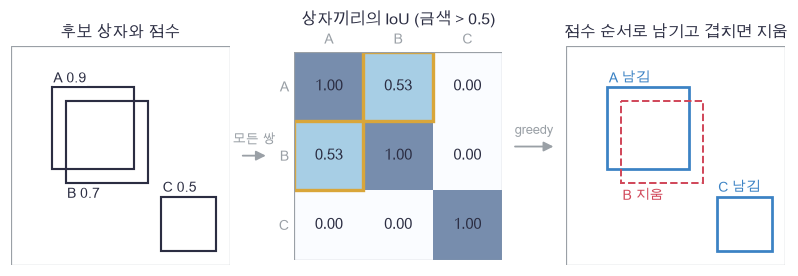

In [48]:
plot_nms_hand(np.zeros((CANVAS, CANVAS)), nms_boxes, nms_scores, nms_names, nms_matrix, nms_keep_hand, 0.5)

🔍 **확인** · 가운데 표에서 대각선은 자기 자신이라 1이고, 금색 칸이 임계값 0.5를 넘은 쌍입니다. A–B 한 쌍뿐입니다.
오른쪽에서 A는 점수가 가장 높아 남고, B는 A와 0.53만큼 겹쳐 지워지고, C는 아무와도 겹치지 않아 남습니다. 점수가 낮아도 자리가 다르면 살아남는다는 점이 중요합니다. NMS는 "중복"만 지우지 "낮은 점수"를 지우지 않습니다.

In [49]:
def nms(boxes, scores, iou_threshold=0.5):
    """greedy 비최대 억제. 점수가 큰 것부터 남기고 그것과 IoU 가 임계값을 넘는 상자를 지웁니다.
    boxes: (M, 4), scores: (M,), iou_threshold: 숫자 → 남긴 상자의 번호 (K,) 정수 배열 (점수 내림차순)."""
    # 쓰는 것: box_iou (1절)
    iou = box_iou(boxes[:, None], boxes[None])            # (M, M): 모든 쌍
    alive = np.ones(len(boxes), dtype=bool)               # (M,): 아직 후보인 상자
    keep = []
    for i in np.argsort(-scores):                         # 점수가 큰 것부터
        if not alive[i]:
            continue
        keep.append(int(i))
        alive &= iou[i] <= iou_threshold                  # 많이 겹치는 상자를 후보에서 지움
        alive[i] = False                                  # 자기 자신도 다시 보지 않음
    return np.array(keep, dtype=int)

In [50]:
# 쓰는 것: nms_boxes, nms_scores, nms_keep_hand (5절 손계산 셀)
np.testing.assert_array_equal(nms(nms_boxes, nms_scores, 0.5), nms_keep_hand)      # 검산: 손계산 {A, C}
np.testing.assert_array_equal(nms(nms_boxes, nms_scores, 1.0), [0, 1, 2])          # 검산: 임계 1.0 이면 아무것도 안 지움
np.testing.assert_array_equal(nms(nms_boxes, np.array([0.5, 0.7, 0.9]), 0.5), [2, 1])   # 검산: 점수를 뒤집으면 B 가 남고 A 가 지워짐
assert set(nms(nms_boxes, nms_scores, 0.0).tolist()) <= {0, 1, 2}, "남긴 번호는 원래 상자 번호여야 합니다"
print("임계 0.5 에서 남은 상자", [nms_names[k] for k in nms(nms_boxes, nms_scores, 0.5)])
print("임계 1.0 에서 남은 상자", [nms_names[k] for k in nms(nms_boxes, nms_scores, 1.0)])

임계 0.5 에서 남은 상자 ['A', 'C']
임계 1.0 에서 남은 상자 ['A', 'B', 'C']


In [51]:
def detect(pred, conf_threshold=0.3, iou_threshold=0.5):
    """격자 출력을 캔버스별 검출 목록으로: 디코딩 → 신뢰도 임계 → NMS.
    pred: (N, S, S, 5+K) → 길이 N 인 목록, 각 원소는 (M, 6) = (점수, 클래스, cx, cy, w, h) (점수 내림차순)."""
    # 쓰는 것: decode_boxes (2절) · nms (5절) · N_CLASSES (📎 데이터 셀)
    all_boxes = decode_boxes(pred)                                        # (N, S, S, 4)
    detections = []
    for n in range(len(pred)):
        scores = pred[n, ..., 4].ravel()                                  # (S·S,): 셀마다의 신뢰도
        classes = pred[n, ..., 5:].reshape(-1, N_CLASSES).argmax(axis=1)  # (S·S,): 셀마다 가장 큰 클래스
        boxes = all_boxes[n].reshape(-1, 4)                               # (S·S, 4)
        over = np.where(scores >= conf_threshold)[0]                      # 임계값을 넘은 셀 번호
        if len(over) == 0:
            detections.append(np.zeros((0, 6)))
            continue
        kept = over[nms(boxes[over], scores[over], iou_threshold)]        # 걸러 낸 뒤 NMS, 원래 번호로 되돌림
        detections.append(np.column_stack([scores[kept], classes[kept], boxes[kept]]))
    return detections

In [52]:
# 쓰는 것: valid_pred, valid_boxes (4절 검증 셀) · canvas_X_valid, canvas_labels_valid (📎 데이터 셀) · detect, nms (5절)
show_index = 0
show_scores = valid_pred[show_index, ..., 4].ravel()                     # (16,): 셀 16개의 신뢰도
show_over = np.where(show_scores >= 0.3)[0]                               # 임계값 0.3 을 넘은 셀
show_before = valid_boxes[show_index].reshape(-1, 4)[show_over]            # (임계 통과 수, 4)
show_after = detect(valid_pred[show_index:show_index + 1], 0.3, 0.5)[0]   # (남은 수, 6) = (점수, 클래스, cx, cy, w, h)
show_gt = canvas_labels_valid[show_index][canvas_labels_valid[show_index, :, 0] >= 0]
assert len(show_after) <= len(show_before), "NMS 는 상자를 늘리지 않습니다"
print(f"캔버스 {show_index}: 셀 16개 중 신뢰도 0.3 이상 {len(show_before)}개 → NMS 뒤 {len(show_after)}개 · 정답 {len(show_gt)}개")
print("남은 상자 (점수, 클래스)\n", show_after[:, :2])

캔버스 0: 셀 16개 중 신뢰도 0.3 이상 6개 → NMS 뒤 5개 · 정답 3개
남은 상자 (점수, 클래스)
 [[0.6472 0.    ]
 [0.6228 0.    ]
 [0.5547 6.    ]
 [0.3523 0.    ]
 [0.3472 0.    ]]


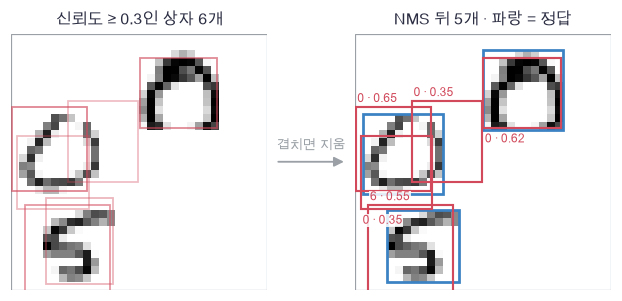

In [53]:
plot_nms_result(canvas_X_valid[show_index, 0], show_before, show_scores[show_over],
                show_after[:, 2:], show_after[:, 0], show_after[:, 1], show_gt[:, 1:], threshold=0.3)

🔍 **확인** · 왼쪽은 신뢰도 0.3을 넘은 상자 전부이고, 오른쪽은 NMS를 거친 뒤입니다. 같은 숫자에 붙어 있던 상자들이 하나로 줄었습니다.
그래도 정답보다 상자가 많을 수 있습니다. 옆 셀이 만든 상자가 임계값보다 IoU가 낮으면 살아남기 때문입니다. 이렇게 살아남은 여분의 상자가 아래에서 precision을 깎습니다.

🔑 **핵심** · 남은 상자에 점수를 매기려면 "어느 예측이 어느 정답을 맞혔나"를 정해야 합니다. 규칙은 하나입니다. **점수가 높은 예측부터** 보면서, 클래스가 같고 아직 짝이 없는 정답 중 IoU가 가장 큰 것을 고르고, 그 IoU가 0.5 이상이면 맞은 것(TP)으로 칩니다. 아니면 틀린 것(FP)입니다. 정답 하나는 한 번만 짝지어지므로 같은 물체에 두 번 답하면 두 번째는 반드시 FP가 됩니다.

> **용어**
>
> - **precision·recall**(15번 5절): precision = 맞은 예측 ÷ 내놓은 예측, recall = 찾은 정답 ÷ 전체 정답.
> - **AP(average precision, 평균 정밀도)**: 점수 임계값을 높은 곳에서 낮은 곳으로 내리며 그린 precision–recall 곡선 아래의 넓이. 임계값 하나를 고르지 않고 전체를 한 숫자로 요약합니다.

$k$번째까지 봤을 때의 누적값으로 두 곡선을 만듭니다. $G$는 전체 정답 수입니다.
$$\mathrm{precision}_k=\frac{\sum_{m\le k}\mathrm{TP}_m}{k},\qquad
\mathrm{recall}_k=\frac{\sum_{m\le k}\mathrm{TP}_m}{G}.$$

precision 곡선은 오르락내리락하므로, 오른쪽의 최댓값으로 감싼 상한을 씁니다(all-point interpolation). 그 상한을 recall 증가분으로 가중합한 것이 AP입니다.
$$\mathrm{AP}=\sum_k(\mathrm{recall}_k-\mathrm{recall}_{k-1})\cdot\max_{m\ge k}\mathrm{precision}_m,\qquad \mathrm{recall}_0=0.$$

15번의 AUC는 양성·음성 **쌍**을 비교해 "점수 순서가 맞는 비율"을 쟀습니다. AP는 순서가 아니라 **내놓은 목록의 앞쪽이 얼마나 깨끗한가**를 잽니다. 검출에서는 음성 후보 수가 정해져 있지 않아 쌍 비교가 어렵기 때문에 AP를 씁니다.

손계산: 검출 4개를 점수 순으로 놓았더니 1·2번째는 맞고 3번째는 틀리고 4번째는 맞았으며, 정답은 모두 5개였습니다.

> **코드**
>
> - `np.cumsum(tp)`: 앞에서부터 차례로 더한 누적합 `(M,)`.
> - `np.maximum.accumulate(p[::-1])[::-1]`: 뒤집어 누적 최댓값을 구하고 다시 뒤집으면 "그 자리 오른쪽의 최댓값"이 됩니다.
> - `np.diff(np.concatenate([[0.0], recall]))`: 앞에 0을 붙인 뒤 이웃 차이. recall 이 얼마씩 늘었는지입니다.

In [54]:
ap_tp = np.array([1., 1., 0., 1.])                       # (4,): 점수 순서대로 맞았으면 1
ap_n_gt = 5                                               # 전체 정답 수
ap_precision = np.cumsum(ap_tp) / np.arange(1, len(ap_tp) + 1)     # (4,): 누적 맞은 수 ÷ 지금까지 내놓은 수
ap_recall = np.cumsum(ap_tp) / ap_n_gt                             # (4,): 누적 맞은 수 ÷ 전체 정답 수
ap_envelope = np.maximum.accumulate(ap_precision[::-1])[::-1]      # (4,): 그 자리 오른쪽의 최대 precision
ap_steps = np.diff(np.concatenate([[0.0], ap_recall]))             # (4,): recall 증가분
ap_hand = float(np.sum(ap_steps * ap_envelope))
print("precision", ap_precision, "\nrecall   ", ap_recall, "\n상한     ", ap_envelope)
print("AP =", ap_hand, "= 0.2·1 + 0.2·1 + 0·0.75 + 0.2·0.75")

precision [1.     1.     0.6667 0.75  ] 
recall    [0.2 0.4 0.4 0.6] 
상한      [1.   1.   0.75 0.75]
AP = 0.55 = 0.2·1 + 0.2·1 + 0·0.75 + 0.2·0.75


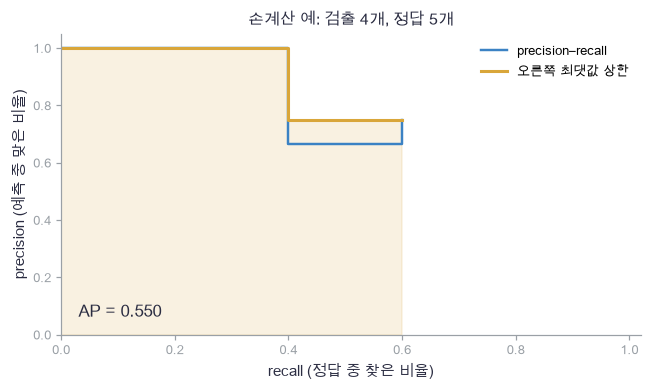

In [55]:
plot_pr_curve(ap_recall, ap_precision, ap_envelope, ap_hand, title="손계산 예: 검출 4개, 정답 5개")

🔍 **확인** · 파란 계단이 precision–recall이고 금색이 오른쪽 최댓값으로 감싼 상한입니다. 세 번째 검출이 틀리면서 precision이 1에서 2/3로 떨어졌지만 recall은 그대로라 곡선이 왼쪽으로 꺾이지 않고 아래로 내려갑니다.
금색 아래 넓이 0.55가 AP입니다. recall이 0.6에서 멈춘 것은 정답 5개 중 3개만 찾았기 때문입니다. 나머지 두 개를 못 찾으면 아무리 precision이 좋아도 AP가 0.6을 넘을 수 없습니다.

In [56]:
def precision_recall_curve(detections, labels, iou_threshold=0.5):
    """점수 순으로 예측을 정답과 매칭해 누적 precision·recall 을 만듭니다. 정답 하나는 한 번만 짝지어집니다.
    detections: detect 의 출력(길이 N 목록), labels: (N, K, 5) → (precision: (M,), recall: (M,))."""
    # 쓰는 것: box_iou (1절)
    rows = [np.column_stack([np.full(len(d), n), d]) for n, d in enumerate(detections) if len(d)]   # 캔버스 번호를 앞에 붙임
    table = np.concatenate(rows) if rows else np.zeros((0, 7))     # (M, 7) = (캔버스, 점수, 클래스, cx, cy, w, h)
    table = table[np.argsort(-table[:, 1])]                        # 1. 모든 캔버스를 섞어 점수 내림차순으로
    is_object = labels[:, :, 0] >= 0                               # (N, K): 빈 자리가 아닌 정답
    matched = np.zeros(labels.shape[:2], dtype=bool)               # (N, K): 이미 짝지어진 정답
    tp = np.zeros(len(table))
    for m in range(len(table)):                                    # 2. 점수가 높은 예측부터
        n, cls = int(table[m, 0]), table[m, 2]
        candidates = is_object[n] & (labels[n, :, 0] == cls) & ~matched[n]     # 같은 캔버스·같은 클래스·아직 안 쓴 정답
        if candidates.sum() == 0:
            continue
        ious = box_iou(table[m, 3:], labels[n, candidates][:, 1:])  # (후보 수,)
        best = int(np.argmax(ious))
        if ious[best] >= iou_threshold:                            # 3. 가장 잘 포개진 정답이 0.5 이상이면 맞은 것
            tp[m] = 1.0
            matched[n, np.where(candidates)[0][best]] = True
    hits = np.cumsum(tp)
    return hits / np.arange(1, len(table) + 1), hits / max(int(is_object.sum()), 1)

In [57]:
def average_precision(precision, recall):
    """all-point 보간 AP: 오른쪽 최댓값으로 감싼 precision 을 recall 증가분으로 가중합.
    precision, recall: (M,) 점수 내림차순 → 숫자 하나."""
    envelope = np.maximum.accumulate(precision[::-1])[::-1]        # (M,): 그 자리 오른쪽의 최대 precision
    steps = np.diff(np.concatenate([[0.0], recall]))               # (M,): recall 증가분
    return float(np.sum(steps * envelope))

In [58]:
# 쓰는 것: ap_precision, ap_recall, ap_hand (5절 손계산 셀) · target_valid, obj_valid (2절 검산 셀) · canvas_labels_valid (📎 데이터 셀) · detect (5절)
np.testing.assert_allclose(average_precision(ap_precision, ap_recall), ap_hand)    # 검산: 손계산 0.55
np.testing.assert_allclose(average_precision(ap_precision, ap_recall), 0.55)       # 검산: 0.2 + 0.2 + 0.15
perfect_pred = target_valid.copy()                                # 정답 타깃을 그대로 예측이라고 두면 완벽한 검출기
perfect_pred[..., 4] = np.where(obj_valid, 1.0, 0.0)              # 책임 셀만 신뢰도 1
perfect_precision, perfect_recall = precision_recall_curve(detect(perfect_pred, 0.5), canvas_labels_valid)
np.testing.assert_allclose(average_precision(perfect_precision, perfect_recall), 1.0)   # 검산: 완벽한 예측이면 AP = 1
random_pred = perfect_pred.copy()
random_pred[..., 4] = np.random.default_rng(1805).uniform(0.5, 1.0, size=random_pred.shape[:3])   # 신뢰도만 무작위
random_precision, random_recall = precision_recall_curve(detect(random_pred, 0.5), canvas_labels_valid)
random_ap = average_precision(random_precision, random_recall)
assert random_ap < 0.3, "신뢰도가 무작위면 AP 가 크게 떨어져야 합니다"
print("완벽한 예측의 AP", average_precision(perfect_precision, perfect_recall), "· 신뢰도만 무작위로 바꾸면", round(random_ap, 4))

완벽한 예측의 AP 1.0 · 신뢰도만 무작위로 바꾸면 0.1345


In [59]:
# 쓰는 것: valid_pred (4절 검증 셀) · canvas_labels_valid (📎 데이터 셀) · detect, precision_recall_curve, average_precision (5절)
model_detections = detect(valid_pred, conf_threshold=0.05)        # AP 는 임계값에 기대지 않도록 낮게 두고 점수 순으로 봅니다
model_precision, model_recall = precision_recall_curve(model_detections, canvas_labels_valid)
model_envelope = np.maximum.accumulate(model_precision[::-1])[::-1]
model_ap = average_precision(model_precision, model_recall)
assert model_ap > 0.3, "학습한 검출기의 AP 가 0.3 은 넘어야 합니다"
print(f"검출 {len(model_precision)}개 · 마지막 precision {model_precision[-1]:.3f} · recall {model_recall[-1]:.3f} · AP {model_ap:.4f}")

검출 639개 · 마지막 precision 0.438 · recall 0.680 · AP 0.4761


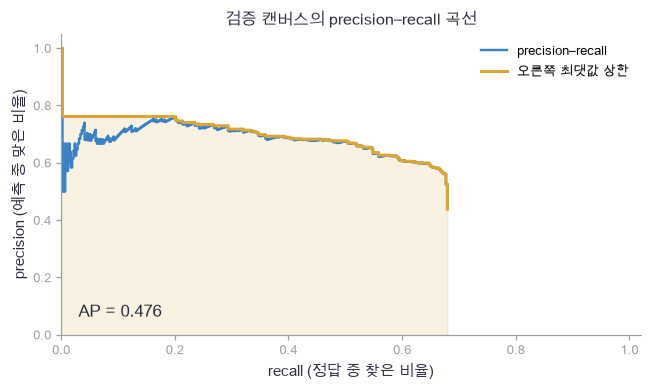

In [60]:
plot_pr_curve(model_recall, model_precision, model_envelope, model_ap)

🔍 **확인** · 곡선이 왼쪽 위에서 시작해 오른쪽 아래로 흘러갑니다. 점수가 높은 앞쪽 검출은 대부분 맞아 precision이 높고, 점수를 낮춰 더 많이 내놓을수록 recall은 올라가지만 precision은 떨어집니다. AP는 이 맞바꿈 전체를 숫자 하나로 요약한 것입니다.
완벽한 예측이 AP 1.0, 상자와 클래스는 정답 그대로 두고 **신뢰도만 무작위**로 섞으면 AP가 0.13까지 떨어집니다. AP가 상자의 정확도만이 아니라 **점수 매기기의 품질**까지 보는 지표라는 뜻입니다.

📎 실제 검출 벤치마크는 IoU 임계값을 0.5부터 0.95까지 0.05씩 올려 가며 AP를 구하고 평균냅니다(COCO의 mAP). 클래스별로 AP를 구한 뒤 클래스 평균을 내기도 합니다. 여기서는 규칙 하나를 끝까지 따라가는 것이 목적이라 IoU 0.5 하나, 클래스별로 나누지 않은 AP 하나만 씁니다(매칭에서는 클래스가 같아야 맞은 것으로 칩니다).

### ✏️ 연습 5 · 억제 한 줄

NMS 안쪽의 한 줄을 채우세요. 지금 남긴 상자 $i$와 다른 상자들의 IoU가 `iou_row` `(M,)`로 주어졌을 때, 임계값을 넘는 자리를 후보 `alive` `(M,)`에서 지운 새 배열을 만듭니다. 검사는 5절 손계산 상자 셋으로 합니다.

In [61]:

def exercise_suppress(alive, iou_row, iou_threshold=0.5):
    """연습 5: 남긴 상자와 많이 겹치는 후보를 지운 alive. alive: (M,) bool, iou_row: (M,) → (M,) bool."""
    assert alive.shape == iou_row.shape, "후보 배열과 IoU 배열의 길이가 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: iou_row 가 iou_threshold 보다 큰 자리를 False 로 만든 새 배열 alive (원래 alive 를 제자리에서 바꾸지 마세요)
    ### 힌트: 5절 nms 의 alive &= iou[i] <= iou_threshold 줄입니다. 여기서는 &= 대신 alive = alive & (…) 로 새 배열을 만듭니다.
    raise NotImplementedError
    return alive


In [62]:

def check_suppress(candidate):
    """5절 손계산 상자 셋의 IoU 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: nms_matrix (5절 손계산 셀)
    start = np.ones(3, dtype=bool)                                    # (3,): 아직 셋 다 후보
    after_a = candidate(start, nms_matrix[0], 0.5)                    # A 를 남긴 뒤
    np.testing.assert_array_equal(after_a, [False, False, True])      # 검산: A 자신(IoU 1)과 B(IoU 0.53)가 지워지고 C 만 남음
    np.testing.assert_array_equal(start, [True, True, True])          # 검산: 원래 배열은 그대로여야 함
    np.testing.assert_array_equal(candidate(start, nms_matrix[0], 1.0), [True, True, True])   # 검산: 임계 1.0 이면 아무도 안 지워짐
    np.testing.assert_array_equal(candidate(np.array([False, True, True]), nms_matrix[2], 0.5), [False, True, False])   # 검산: 이미 지워진 자리는 계속 False
    print("억제 한 줄: 손계산과 일치합니다.")


run_check(check_suppress, exercise_suppress, hint="alive = alive & (iou_row <= iou_threshold)")


☐ exercise_suppress: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: alive = alive & (iou_row <= iou_threshold)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
alive = alive & (iou_row <= iou_threshold)
```

</details>

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · IoU 벡터화 (1절)

상자 묶음 `A` `(M, 4)`와 `B` `(K, 4)`의 **모든 쌍**의 IoU `(M, K)`를 만드는 두 줄을 채우세요. 모서리를 브로드캐스팅 모양으로 푸는 줄은 써 두었습니다.

In [63]:
def exercise_box_iou(A, B):
    """연습 A: 모든 쌍의 IoU. A: (M, 4), B: (K, 4) 상자 (cx, cy, w, h) → (M, K)."""
    assert A.shape[1] == 4, "상자는 (cx, cy, w, h) 네 숫자여야 합니다"
    assert B.shape[1] == 4, "상자는 (cx, cy, w, h) 네 숫자여야 합니다"
    ax1, ay1, ax2, ay2 = box_corners(A[:, None])          # (M, 1) 넷: 길이 1인 축을 끼워 모든 쌍에 맞춤
    bx1, by1, bx2, by2 = box_corners(B[None])             # (1, K) 넷
    area_a, area_b = A[:, None, 2] * A[:, None, 3], B[None, :, 2] * B[None, :, 3]   # (M, 1), (1, K): 각 상자의 넓이
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 교집합 넓이 inter (모양 (M, K)) 와 IoU (모양 (M, K))
    ### 힌트: inter 는 연습 1과 같은 줄이고, IoU 는 inter / (area_a + area_b − inter) 입니다.
    raise NotImplementedError
    return iou

In [64]:
def check_box_iou(candidate):
    """1절 손계산 0.2 와 자기 자신 1, 떨어진 상자 0 으로 검사하고 box_iou 와 대조합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: box_corners, box_iou (1절)
    example_A = np.array([[12., 12., 12., 12.], [26., 26., 8., 8.]])       # (2, 4)
    example_B = np.array([[18., 15., 12., 6.], [12., 12., 12., 12.]])      # (2, 4)
    actual = candidate(example_A, example_B)
    assert actual.shape == (2, 2), f"모든 쌍의 IoU 는 (M, K) = (2, 2)여야 하는데 {actual.shape}입니다"
    np.testing.assert_allclose(actual, [[0.2, 1.0], [0.0, 0.0]])           # 검산: 손계산 36/180, 자기 자신, 떨어진 두 쌍
    rng_check = np.random.default_rng(1806)
    random_A = np.column_stack([rng_check.uniform(4, 28, size=(5, 2)), rng_check.uniform(2, 8, size=(5, 2))])   # (5, 4)
    random_B = np.column_stack([rng_check.uniform(4, 28, size=(3, 2)), rng_check.uniform(2, 8, size=(3, 2))])   # (3, 4)
    np.testing.assert_allclose(candidate(random_A, random_B), box_iou(random_A[:, None], random_B[None]))       # 검산: 1절 box_iou 와 같음
    print("모든 쌍의 IoU: 손계산·box_iou 와 일치합니다.")


run_check(check_box_iou, exercise_box_iou,
          hint="inter = np.clip(np.minimum(ax2, bx2) - np.maximum(ax1, bx1), 0, None) * np.clip(np.minimum(ay2, by2) - np.maximum(ay1, by1), 0, None) · iou = inter / (area_a + area_b - inter)")

☐ exercise_box_iou: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: inter = np.clip(np.minimum(ax2, bx2) - np.maximum(ax1, bx1), 0, None) * np.clip(np.minimum(ay2, by2) - np.maximum(ay1, by1), 0, None) · iou = inter / (area_a + area_b - inter)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
inter = np.clip(np.minimum(ax2, bx2) - np.maximum(ax1, bx1), 0, None) * np.clip(np.minimum(ay2, by2) - np.maximum(ay1, by1), 0, None)
iou = inter / (area_a + area_b - inter)
```

</details>

### ✏️ 연습 B · 셀 안 상대 좌표 (2절)

책임 셀 `(row, col)`이 이미 주어졌을 때, 중심 `cx`, `cy`(캔버스 비율)를 **셀 안 상대 좌표** $t_x, t_y\in[0,1)$로 바꾸는 한 줄을 채우세요. 연습 2가 셀 번호를 물었다면 여기는 그 셀 안에서의 위치입니다.

In [65]:
def exercise_cell_offsets(cx, cy, row, col, S):
    """연습 B: 캔버스 비율 중심을 셀 안 상대 좌표로. cx, cy: 숫자, row, col: 책임 셀, S: 격자 한 변 → (tx, ty) 숫자 둘."""
    assert 0 <= col < S, "열 번호는 0 이상 S 미만이어야 합니다"
    assert 0 <= row < S, "행 번호는 0 이상 S 미만이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: tx, ty = 중심에 S 를 곱한 뒤 셀 번호를 뺀 값 (둘 다 0 이상 1 미만)
    ### 힌트: 2절 수식 t_x = c_x·S − col, t_y = c_y·S − row 그대로입니다. 가로는 col, 세로는 row 입니다.
    raise NotImplementedError
    return tx, ty

In [66]:
def check_cell_offsets(candidate):
    """손계산 두 경우와 2절 그림의 타깃 두 칸으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: grid_boxes, grid_cells, grid_target (2절 계산 셀)
    np.testing.assert_allclose(candidate(0.1, 0.1, 0, 0, 4), (0.4, 0.4))       # 검산: 0.1 × 4 = 0.4, 셀 0 이라 그대로
    np.testing.assert_allclose(candidate(0.9, 0.3, 1, 3, 4), (0.6, 0.2))       # 검산: 3.6 − 3 = 0.6, 1.2 − 1 = 0.2
    for box, (row, col) in zip(grid_boxes, grid_cells):
        offsets = candidate(box[0], box[1], row, col, 4)
        assert 0 <= offsets[0] < 1, "셀 안 상대 좌표 t_x 는 0 이상 1 미만이어야 합니다"
        np.testing.assert_allclose(offsets, grid_target[row, col, 0:2])         # 검산: 2절에서 채운 타깃의 앞 두 칸
    print("셀 안 상대 좌표: 손계산·2절 타깃과 일치합니다.")


run_check(check_cell_offsets, exercise_cell_offsets, hint="tx, ty = cx * S - col, cy * S - row")

☐ exercise_cell_offsets: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: tx, ty = cx * S - col, cy * S - row


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
tx, ty = cx * S - col, cy * S - row
```

</details>

### ✏️ 연습 C · 좌표 묶음과 그 기울기 (3절)

YOLO 손실의 **좌표 묶음**(배치 평균)과 그 $t_x, t_y$ 칸 기울기를 만드는 두 줄을 채우세요. 오차 두 개를 구하는 줄은 써 두었습니다. 책임 셀만 이 항을 받는다는 점, 평균은 캔버스 축에서만 낸다는 점에 주의하세요.

In [67]:
def exercise_coord_term(pred, target, obj, lam_coord=5.0):
    """연습 C: 좌표 묶음의 값과 t_x, t_y 기울기. pred, target: (N, S, S, 5+K), obj: (N, S, S) bool → (term: 숫자, dxy: (N, S, S, 2))."""
    N = len(pred)
    d_xy = pred[..., 0:2] - target[..., 0:2]                      # (N, S, S, 2): 중심 오차
    d_wh = np.sqrt(pred[..., 2:4]) - np.sqrt(target[..., 2:4])    # (N, S, S, 2): √ 안에서 뺀 크기 오차
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 좌표 묶음 term (숫자 하나) 과 t_x, t_y 칸의 기울기 dxy (모양 (N, S, S, 2))
    ### 힌트: 3절 yolo_loss 의 "좌표" 항과 dpred[..., 0:2] 줄입니다. 네 제곱을 셀에서 모두 더하고 N 으로 나눕니다. mask 는 obj 와 obj[..., None] 입니다.
    raise NotImplementedError
    return term, dxy

In [68]:
def check_coord_term(candidate):
    """3절 손계산 예(좌표 항 0.4, 기울기 2.0)로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: loss_pred, loss_target, loss_obj (3절 손계산 셀) · yolo_loss (3절)
    term, dxy = candidate(loss_pred, loss_target, loss_obj)
    assert np.ndim(term) == 0, f"좌표 묶음은 숫자 하나여야 하는데 모양이 {np.shape(term)}입니다"
    assert dxy.shape == loss_pred[..., 0:2].shape, f"기울기는 (N, S, S, 2)여야 하는데 {dxy.shape}입니다"
    np.testing.assert_allclose(term, 0.4)                                   # 검산: 손계산 5 × (0.04 + 0 + 0.04 + 0)
    np.testing.assert_allclose(dxy[0, 0, 0], [2.0, 0.0])                    # 검산: 2 × 5 × (0.7 − 0.5) 와 맞힌 쪽 0
    np.testing.assert_allclose(dxy[0, 0, 1], [0.0, 0.0])                    # 검산: 빈 셀은 좌표 항을 받지 않음
    np.testing.assert_allclose(term, yolo_loss(loss_pred, loss_target, loss_obj)[2]["좌표"])        # 검산: 3절 yolo_loss 의 좌표 항
    print("좌표 묶음과 기울기: 손계산과 일치합니다.")


run_check(check_coord_term, exercise_coord_term,
          hint="term = lam_coord * np.sum(obj * (np.sum(d_xy ** 2, -1) + np.sum(d_wh ** 2, -1))) / N · dxy = 2 * lam_coord * obj[..., None] * d_xy / N")

☐ exercise_coord_term: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: term = lam_coord * np.sum(obj * (np.sum(d_xy ** 2, -1) + np.sum(d_wh ** 2, -1))) / N · dxy = 2 * lam_coord * obj[..., None] * d_xy / N


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
term = lam_coord * np.sum(obj * (np.sum(d_xy ** 2, -1) + np.sum(d_wh ** 2, -1))) / N
dxy = 2 * lam_coord * obj[..., None] * d_xy / N
```

</details>

### ✏️ 연습 D · precision·recall 한 점 (5절)

점수 순으로 맞았는지 적은 `tp` `(M,)`과 전체 정답 수 `n_gt`에서 **누적 precision과 recall** 두 줄을 채우세요. 분모가 서로 다른 것이 핵심입니다. 하나는 "지금까지 내놓은 수", 다른 하나는 "전체 정답 수"입니다.

In [69]:
def exercise_precision_recall(tp, n_gt):
    """연습 D: 누적 precision 과 recall. tp: (M,) 점수 내림차순의 0/1, n_gt: 전체 정답 수 → (precision: (M,), recall: (M,))."""
    assert n_gt > 0, "전체 정답 수는 1 이상이어야 합니다"
    assert np.all((tp == 0) | (tp == 1)), "tp 는 맞았으면 1, 틀렸으면 0 이어야 합니다"
    hits = np.cumsum(tp)                                   # (M,): 앞에서부터 맞은 수의 누적합
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: precision (M,) = 누적 맞은 수 ÷ 지금까지 내놓은 수, recall (M,) = 누적 맞은 수 ÷ 전체 정답 수
    ### 힌트: 5절 손계산 셀의 두 줄입니다. "지금까지 내놓은 수"는 1, 2, …, M 이므로 np.arange(1, len(tp) + 1) 입니다.
    raise NotImplementedError
    return precision, recall

In [70]:
def check_precision_recall(candidate):
    """5절 손계산(검출 4개, 정답 5개)과 완벽한 목록으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: ap_precision, ap_recall, ap_hand (5절 손계산 셀) · average_precision (5절)
    precision, recall = candidate(np.array([1., 1., 0., 1.]), 5)
    assert precision.shape == (4,), f"precision 은 검출 수와 같은 (4,)여야 하는데 {precision.shape}입니다"
    np.testing.assert_allclose(precision, [1., 1., 2 / 3, 3 / 4])      # 검산: 손계산 1/1, 2/2, 2/3, 3/4
    np.testing.assert_allclose(recall, [.2, .4, .4, .6])               # 검산: 손계산 1/5, 2/5, 2/5, 3/5
    np.testing.assert_allclose([precision, recall], [ap_precision, ap_recall])   # 검산: 5절 그림의 두 곡선
    np.testing.assert_allclose(average_precision(precision, recall), ap_hand)    # 검산: 두 곡선에서 나온 AP 0.55
    perfect = candidate(np.ones(3), 3)
    np.testing.assert_allclose(perfect, [[1., 1., 1.], [1 / 3, 2 / 3, 1.]])     # 검산: 셋을 다 맞히면 precision 1, recall 이 1까지 오름
    print("precision·recall 한 점: 손계산과 일치합니다.")


run_check(check_precision_recall, exercise_precision_recall,
          hint="precision = hits / np.arange(1, len(tp) + 1) · recall = hits / n_gt")

☐ exercise_precision_recall: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: precision = hits / np.arange(1, len(tp) + 1) · recall = hits / n_gt


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
precision = hits / np.arange(1, len(tp) + 1)
recall = hits / n_gt
```

</details>

### 🔍 완성 예제 · $\lambda_{noobj}$를 0.5에서 5로

3절에서 $\lambda_{noobj}$는 "빈 셀이 훨씬 많으니 그 항을 줄이자"는 가중치였습니다. 반대로 열 배로 키우면 어떻게 될까요?
셀 16개 중 책임 셀은 평균 2개이므로, $\lambda_{noobj}=5$면 noobj 항의 총 무게가 obj 항의 $14\times5\,/\,2=35$배가 됩니다.
같은 초기값·같은 미니배치 순서로 700스텝을 다시 학습하고, 상자 정확도와 신뢰도, 그리고 precision·recall을 비교합니다.

In [71]:
# 쓰는 것: train_detector, detector_forward (4절) · valid_pred, valid_iou (4절 검증 셀) · model_ap, model_recall (5절 평가 셀) · canvas_X_valid, canvas_labels_valid (📎 데이터 셀) · target_valid, obj_valid (2절 검산 셀) · decode_boxes (2절) · box_iou (1절) · detect, precision_recall_curve, average_precision (5절)
variant_params, variant_history = train_detector(lam_noobj=5.0)
variant_pred, _ = detector_forward(canvas_X_valid, variant_params)
variant_iou = box_iou(decode_boxes(variant_pred), decode_boxes(target_valid))[obj_valid]     # (물체 수,): 책임 셀 상자 정확도
variant_conf_obj = variant_pred[..., 4][obj_valid].mean()
variant_conf_noobj = variant_pred[..., 4][~obj_valid].mean()
variant_at_threshold = sum(len(d) for d in detect(variant_pred, conf_threshold=0.3))          # 임계값 0.3 을 넘긴 검출 수
main_at_threshold = sum(len(d) for d in detect(valid_pred, conf_threshold=0.3))
variant_precision, variant_recall = precision_recall_curve(detect(variant_pred, conf_threshold=0.05), canvas_labels_valid)
variant_ap = average_precision(variant_precision, variant_recall)
print(f"λ_noobj = 0.5 : 상자 IoU {valid_iou.mean():.3f} · 신뢰도 책임셀 {valid_pred[..., 4][obj_valid].mean():.4f} 빈셀 {valid_pred[..., 4][~obj_valid].mean():.4f}")
print(f"λ_noobj = 5.0 : 상자 IoU {variant_iou.mean():.3f} · 신뢰도 책임셀 {variant_conf_obj:.4f} 빈셀 {variant_conf_noobj:.4f}")
print(f"임계값 0.3 을 넘긴 검출 수: {main_at_threshold}개 → {variant_at_threshold}개")
print(f"AP: {model_ap:.4f} → {variant_ap:.4f} · 마지막 recall: {model_recall[-1]:.3f} → {variant_recall[-1] if len(variant_recall) else 0.0:.3f}")
assert variant_conf_obj < valid_pred[..., 4][obj_valid].mean(), "λ_noobj 를 키우면 신뢰도가 전체적으로 눌려야 합니다"
assert variant_ap < model_ap, "신뢰도가 무너지면 AP 도 떨어져야 합니다"

λ_noobj = 0.5 : 상자 IoU 0.716 · 신뢰도 책임셀 0.6224 빈셀 0.0549
λ_noobj = 5.0 : 상자 IoU 0.704 · 신뢰도 책임셀 0.0171 빈셀 0.0150
임계값 0.3 을 넘긴 검출 수: 434개 → 0개
AP: 0.4761 → 0.0159 · 마지막 recall: 0.680 → 0.022


🔍 **확인** · **상자 자체는 거의 그대로입니다.** 책임 셀의 IoU는 0.71 근처로 둘이 비슷합니다. 좌표 항은 $\lambda_{noobj}$와 상관없이 그대로 걸리기 때문입니다.
무너진 것은 **신뢰도**입니다. $\lambda_{noobj}=5$에서는 책임 셀의 신뢰도까지 0.02 근처로 눌려, 빈 셀의 신뢰도와 구별되지 않습니다. 손실 입장에서는 빈 셀 14개를 확실히 0으로 만드는 이득이 책임 셀 2개를 맞히는 이득보다 훨씬 크기 때문입니다.
그 결과 임계값 0.3에서는 검출이 하나도 나오지 않아 recall이 0이 되고, 임계값을 0.05까지 낮춰도 AP가 0.48에서 0.02로 떨어집니다. precision이 올라간 것이 아니라 **아무 말도 하지 않게 된 것**입니다.
가중치는 "무엇을 더 중요하게 볼지"를 정하지만, 한쪽으로 너무 기울면 모델이 쉬운 쪽만 답하고 어려운 쪽을 포기합니다. $\lambda_{noobj}$를 1.5 정도로만 올리면 신뢰도가 살아 있는 채로 precision이 조금 오르고 recall이 조금 내려갑니다. 위 셀의 `5.0`을 `1.5`로 바꿔 직접 확인해 보세요.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 격자 셀 하나가 무엇을 책임지는지, 그리고 물체 수가 달라도 출력 모양이 왜 그대로인지 설명할 수 있나요? → 2절
- **수식:** IoU와 네 묶음 손실을 shape와 함께 쓰고, $\sqrt{\hat w}$ 항의 미분에 왜 $1/(2\sqrt{\hat w})$가 붙는지 말할 수 있나요? → 1·3절
- **구현:** encode → decode 왕복, mask를 곱한 미분, NMS의 세 줄을 보지 않고 쓸 수 있나요? → 2·3·5절
- **변형:** $\lambda_{noobj}$나 신뢰도 임계값을 올리면 precision과 recall이 각각 어느 쪽으로 움직일지 미리 말할 수 있나요? → 3·5절

다음은 18 U-Net입니다. 이번에는 격자 셀마다 답을 하나씩 냈지만, 거기서는 **화소마다** 답을 냅니다. 줄였던 특성 맵을 다시 키우면서 앞 단계의 자세한 정보를 이어 붙이는 구조를 봅니다.

📎 [Redmon 등, 2016](https://arxiv.org/abs/1506.02640)이 "검출을 회귀 문제 하나로 푼다"는 이 구성을 처음 제안한 논문입니다. 이후 버전들은 크기가 다른 anchor 상자를 두거나(v2·v3), 중심점만으로 배정하거나(anchor-free), 상자 손실을 제곱합 대신 IoU 계열(GIoU·CIoU)로 바꾸고, 여러 해상도의 격자를 함께 씁니다. 배정 규칙과 상자 손실이 바뀌는 것이지 **"좌표 + objectness + 클래스" 세 묶음을 격자 위에서 한 번에 낸다**는 뼈대는 그대로입니다. 이 노트북의 캔버스 데이터와 모델은 설명을 위해 새로 구성한 예제이며 원논문의 재현 실험이 아닙니다.